In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1. Data Loading & Preprocessing using SKLearn
# ==========================================

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_raw, y_raw = mnist.data, mnist.target.astype(int)

# Normalization [0, 1]
X_normalized = X_raw / 255.0

# Stratified Split (60% Train, 20% Val, 20% Test) using SKLearn

# First split: 80% Train+Val, 20% Test
X_train_val, X_test_raw, y_train_val, y_test_raw = train_test_split(X_normalized, y_raw, test_size=0.20, random_state=42, stratify=y_raw)

# Second split: From 80%, split 60% Train and 20% Val (0.25 of 80% = 20%)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)


# ==========================================
# 2. Filter Binary Digits (0 vs 1) + Dummy Feature
# ==========================================
def process_binary_data(X_data, y_data):
    # Filter for 0 and 1 digits only
    tr_con = (y_data == 0) | (y_data == 1)
    X_bin = X_data[tr_con]
    y_bin = (y_data[tr_con] == 1)

    # Convert to PyTorch Tensors
    X_tensor = torch.tensor(X_bin, dtype=torch.float32)
    y_tensor = torch.tensor(y_bin, dtype=torch.float32).unsqueeze(1)

    # Add Dummy Bias Feature (Column of 1s -> 785 features)
    ones = torch.ones((X_tensor.size(0), 1))
    X_with_dummy = torch.cat([X_tensor, ones], dim=1)

    return X_with_dummy, y_tensor

X_train, y_train = process_binary_data(X_train_raw, y_train_raw)
X_val, y_val     = process_binary_data(X_val_raw, y_val_raw)
X_test, y_test   = process_binary_data(X_test_raw, y_test_raw)


# ==========================================
# 3. Pure Scratch Functions
# ==========================================
def sigmoid(z):
    return 1.0 / (1.0 + torch.exp(-z))

def tr_mlt(X, W):
    z = torch.matmul(X, W)
    return sigmoid(z)

def compute_bce_loss(y_pred, target):
    N = target.size(0)
    loss = - (1.0 / N) * torch.sum(target * torch.log(y_pred) + (1.0 - target) * torch.log(1.0 - y_pred))
    return loss

def compute_gradient(X, y_pred, target):
    N = X.size(0)
    drev_W = (1.0 / N) * torch.matmul(X.T, (y_pred - target))
    return drev_W

def compute_accuracy(y_pred, target):
    preds = (y_pred >= 0.5)
    return (preds == target).float().mean()

def predict_class(X, W):
    y_pred = tr_mlt(X, W)
    return (y_pred >= 0.5)

def train_binary_scratch(X_train, y_train, X_val, y_val, lr=0.01, steps=300):
    num_features = X_train.shape[1]
    W = torch.randn((num_features, 1), dtype=torch.float32) * 0.01

    train_losses, val_losses, train_accs, val_accs = [],[],[],[]


    for step in range(steps):

        y_pred_train = tr_mlt(X_train, W)#segmoided out
        train_loss = compute_bce_loss(y_pred_train, y_train)
        train_acc = compute_accuracy(y_pred_train, y_train)

        # Gradient Descent Step (Manual Gradient Calculation)
        dW = compute_gradient(X_train, y_pred_train, y_train)
        W = W - lr * dW

        # Validation Step
        y_pred_val = tr_mlt(X_val, W)
        val_loss = compute_bce_loss(y_pred_val, y_val)
        val_acc = compute_accuracy(y_pred_val, y_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if (step + 1) % 50 == 0 or step == 0:
         print(f"step [{step+1}/{steps}] :\nTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%\n\n")

    return W, train_losses, val_losses, train_accs, val_accs





--- (Binary Logistic Regression) ---
step [1/300] :
Train Loss: 0.6929 | Val Loss: 0.6617 | Val Acc: 50.10%


step [50/300] :
Train Loss: 0.2033 | Val Loss: 0.2008 | Val Acc: 99.76%


step [100/300] :
Train Loss: 0.1201 | Val Loss: 0.1191 | Val Acc: 99.73%


step [150/300] :
Train Loss: 0.0874 | Val Loss: 0.0867 | Val Acc: 99.73%


step [200/300] :
Train Loss: 0.0699 | Val Loss: 0.0691 | Val Acc: 99.76%


step [250/300] :
Train Loss: 0.0588 | Val Loss: 0.0581 | Val Acc: 99.76%


step [300/300] :
Train Loss: 0.0513 | Val Loss: 0.0504 | Val Acc: 99.76%



Final Test Accuracy (Digit 0 vs Digit 1): 99.56%



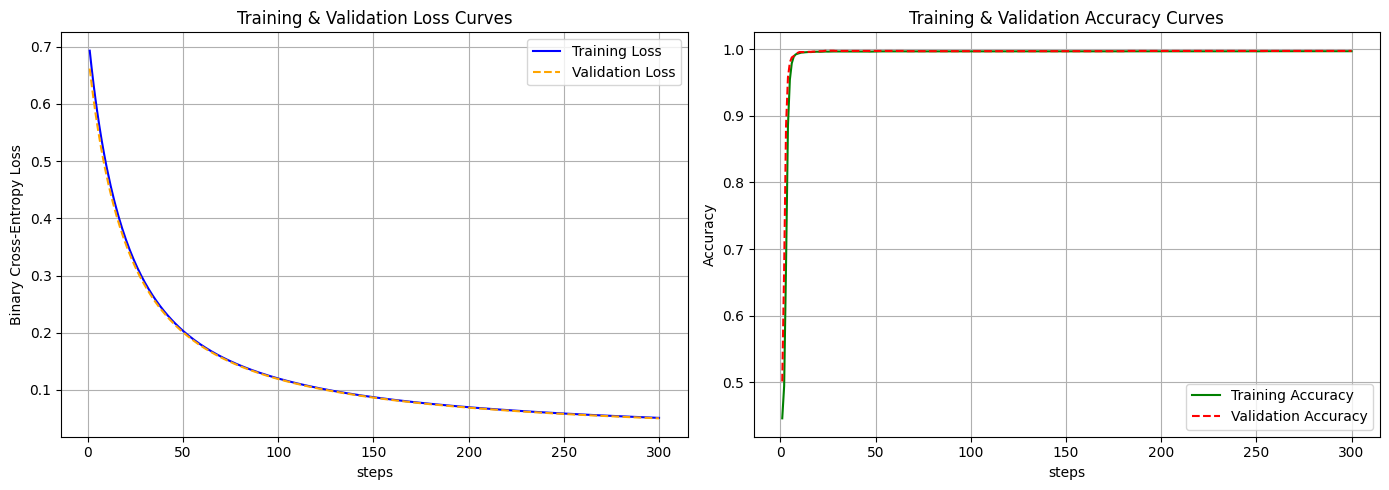

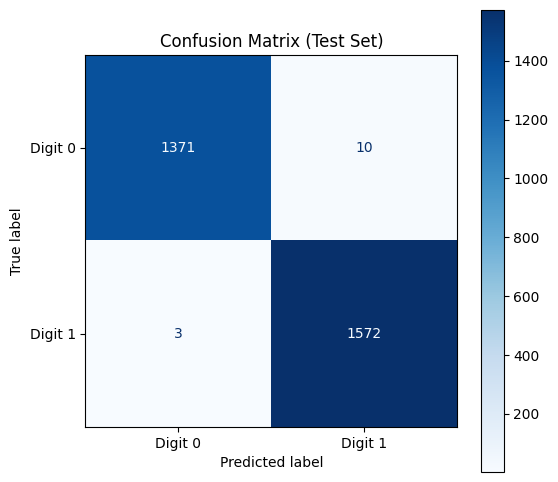

In [2]:
# ==========================================
# 4. Training Execution & Evaluation
# ==========================================
print("\n--- (Binary Logistic Regression) ---")
W_trained, train_losses, val_losses, train_accs, val_accs = train_binary_scratch(X_train, y_train, X_val, y_val, lr=0.01, steps=300)

# Test Set Evaluation
test_preds = predict_class(X_test, W_trained)
test_acc = (test_preds == y_test).float().mean()

print(f"\n==========================================")
print(f"Final Test Accuracy (Digit 0 vs Digit 1): {test_acc * 100:.2f}%")
print(f"==========================================\n")


# ==========================================
# 5. Plotting
# ==========================================
steps_len = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Loss Curves
plt.subplot(1, 2, 1)
plt.plot(steps_len, train_losses, label="Training Loss", color="blue")
plt.plot(steps_len, val_losses, label="Validation Loss", color="orange", linestyle="--")
plt.title("Training & Validation Loss Curves")
plt.xlabel("steps")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)

# Plot 2: Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(steps_len, train_accs, label="Training Accuracy", color="green")
plt.plot(steps_len, val_accs, label="Validation Accuracy", color="red", linestyle="--")
plt.title("Training & Validation Accuracy Curves")
plt.xlabel("steps")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot 3: Confusion Matrix
cm = confusion_matrix(y_test.numpy(), test_preds.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Digit 0', 'Digit 1'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [3]:
def softmax(z):
    exp_z = torch.exp(z - torch.max(z, dim=1, keepdim=True).values)
    return exp_z / torch.sum(exp_z, dim=1, keepdim=True)


def forward_multiclass(X, W):
    z = torch.matmul(X, W)
    return softmax(z)


def compute_cross_entropy_loss(y_pred, target):

    N = target.size(0)
    correct_class_probs = y_pred[torch.arange(N),target]
    loss = -(1.0 / N) * torch.sum(torch.log(correct_class_probs))
    return loss


def compute_multiclass_gradient(X, y_pred, target):
    N = X.size(0)
    error = y_pred.clone()
    # Subtract 1 from probability of correct class
    error[torch.arange(N), target] -= 1
    dW = (1.0 / N) * torch.matmul(X.T, error)
    return dW


def compute_multiclass_accuracy(y_pred, target):
    preds = torch.argmax(y_pred, dim=1)
    return (preds == target).float().mean()

def predict_multiclass(X, W):
    y_pred = forward_multiclass(X, W)
    return torch.argmax(y_pred, dim=1)


# ==========================================
# 4. Multiclass Training
# ==========================================

def train_multiclass_scratch( X_train,y_train,X_val,y_val, lr=0.01,steps=2000):

    num_features = X_train.shape[1]
    num_classes = 10

    # W: [785, 10]
    W = torch.randn((num_features, num_classes),dtype=torch.float32) * 0.01

    train_losses ,val_losses,train_accs,val_accs = [] ,[] ,[] ,[]

    for step in range(steps):


        y_pred_train = forward_multiclass(X_train, W)

        train_loss = compute_cross_entropy_loss(y_pred_train,y_train )

        train_acc = compute_multiclass_accuracy(y_pred_train,y_train)

        # Gradient
        dW = compute_multiclass_gradient(X_train, y_pred_train, y_train)

        W = W - lr * dW

        y_pred_val = forward_multiclass(X_val, W)

        val_loss = compute_cross_entropy_loss(y_pred_val,y_val )

        val_acc = compute_multiclass_accuracy(y_pred_val,y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        train_accs.append(train_acc.item())
        val_accs.append(val_acc.item())

        if (step + 1) % 250 == 0 or step == 0:

            print( f"step [{step+1}/{steps}] :\n" f"Train Loss: {train_loss:.4f} | " f"Val Loss: {val_loss:.4f} | " f"Val Acc: {val_acc*100:.2f}%\n" )


    return W, train_losses, val_losses, train_accs, val_accs

step [1/2000] :
Train Loss: 2.3063 | Val Loss: 2.2960 | Val Acc: 11.23%

step [250/2000] :
Train Loss: 1.0856 | Val Loss: 1.0854 | Val Acc: 81.39%

step [500/2000] :
Train Loss: 0.8001 | Val Loss: 0.8007 | Val Acc: 83.98%

step [750/2000] :
Train Loss: 0.6788 | Val Loss: 0.6794 | Val Acc: 85.18%

step [1000/2000] :
Train Loss: 0.6102 | Val Loss: 0.6107 | Val Acc: 85.98%

step [1250/2000] :
Train Loss: 0.5653 | Val Loss: 0.5658 | Val Acc: 86.64%

step [1500/2000] :
Train Loss: 0.5333 | Val Loss: 0.5337 | Val Acc: 87.07%

step [1750/2000] :
Train Loss: 0.5090 | Val Loss: 0.5095 | Val Acc: 87.38%

step [2000/2000] :
Train Loss: 0.4899 | Val Loss: 0.4904 | Val Acc: 87.64%



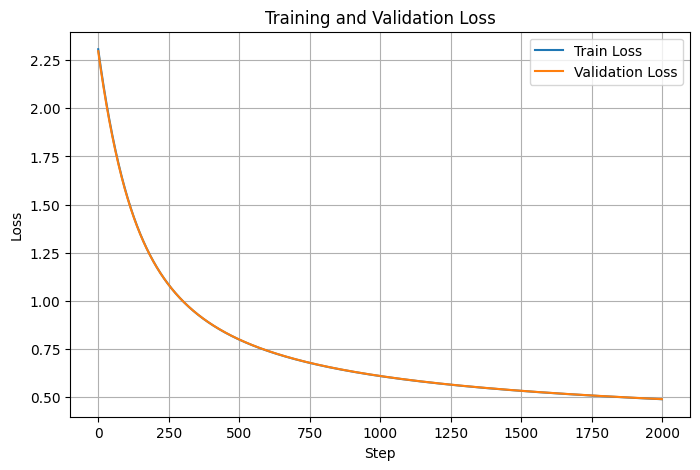

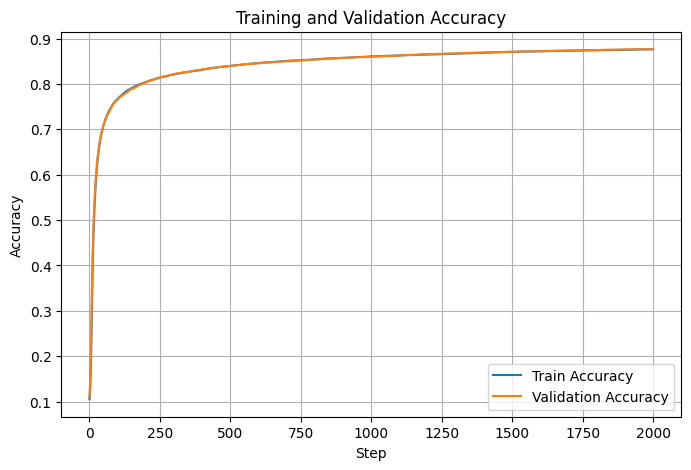

Scratch Test Accuracy: 87.54%


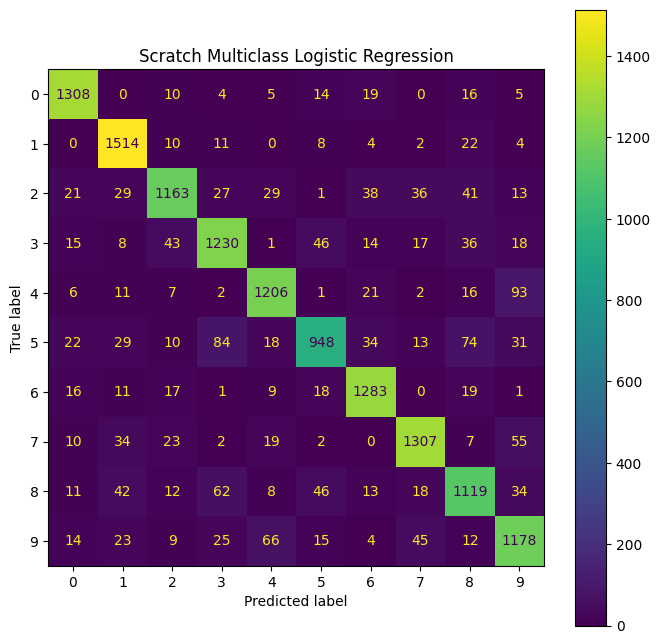

Digit 0: 94.71%
Digit 1: 96.13%
Digit 2: 83.19%
Digit 3: 86.13%
Digit 4: 88.35%
Digit 5: 75.06%
Digit 6: 93.31%
Digit 7: 89.58%
Digit 8: 81.98%
Digit 9: 84.69%


In [4]:
X_train = torch.tensor(X_train_raw, dtype=torch.float32)
y_train=torch.tensor(y_train_raw, dtype=torch.long)
X_val=torch.tensor(X_val_raw, dtype=torch.float32)
y_val=torch.tensor(y_val_raw, dtype=torch.long)
X_test = torch.tensor(X_test_raw, dtype=torch.float32)
y_test = torch.tensor(y_test_raw, dtype=torch.long)
W, train_losses, val_losses, train_accs, val_accs = train_multiclass_scratch(X_train, y_train,X_val, y_val , lr=0.01,steps=2000)



# ==========================================
# 6. Plot Loss
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


# ==========================================
# 7. Plot Accuracy
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


# ==========================================
# 8. Test - Scratch Model
# ==========================================

test_preds_scratch = predict_multiclass(X_test, W)

test_acc_scratch = (test_preds_scratch == y_test).float().mean()

print(f"Scratch Test Accuracy: "f"{test_acc_scratch * 100:.2f}%")


# ==========================================
# 9. Confusion Matrix - Scratch
# ==========================================

cm = confusion_matrix( y_test.numpy(),test_preds_scratch.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[ '0', '1', '2', '3', '4','5', '6', '7', '8', '9'])

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)

plt.title("Scratch Multiclass Logistic Regression")
plt.show()
for class_id in range(10):

    # Select samples that actually belong to this class
    tr_con = (y_test == class_id)
    # Number of samples in this class
    total = tr_con.sum()
    # Number of correctly classified samples
    correct = (test_preds_scratch[tr_con] == y_test[tr_con]).sum()
    class_accuracy = correct.float() / total.float()
    print(f"Digit {class_id}: "f"{class_accuracy * 100:.2f}%")




step [1/2000] :
Train Loss: 2.3107 | Val Loss: 2.2991 | Val Acc: 10.81%

step [250/2000] :
Train Loss: 1.0821 | Val Loss: 1.0816 | Val Acc: 81.22%

step [500/2000] :
Train Loss: 0.7981 | Val Loss: 0.7984 | Val Acc: 84.04%

step [750/2000] :
Train Loss: 0.6775 | Val Loss: 0.6779 | Val Acc: 85.44%

step [1000/2000] :
Train Loss: 0.6094 | Val Loss: 0.6098 | Val Acc: 86.09%

step [1250/2000] :
Train Loss: 0.5649 | Val Loss: 0.5653 | Val Acc: 86.68%

step [1500/2000] :
Train Loss: 0.5331 | Val Loss: 0.5335 | Val Acc: 87.07%

step [1750/2000] :
Train Loss: 0.5089 | Val Loss: 0.5094 | Val Acc: 87.41%

step [2000/2000] :
Train Loss: 0.4899 | Val Loss: 0.4904 | Val Acc: 87.59%



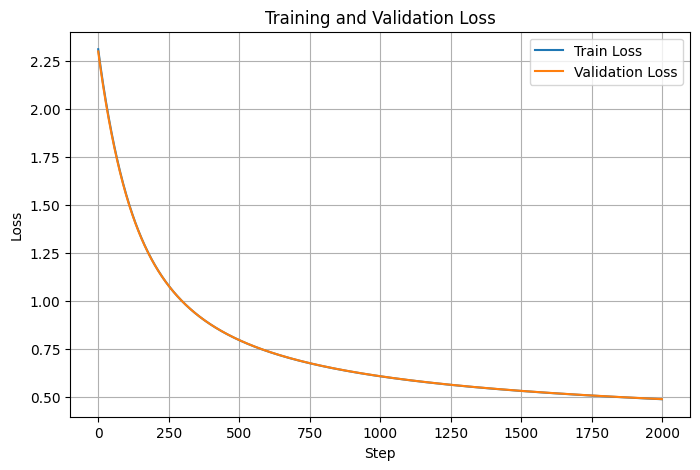

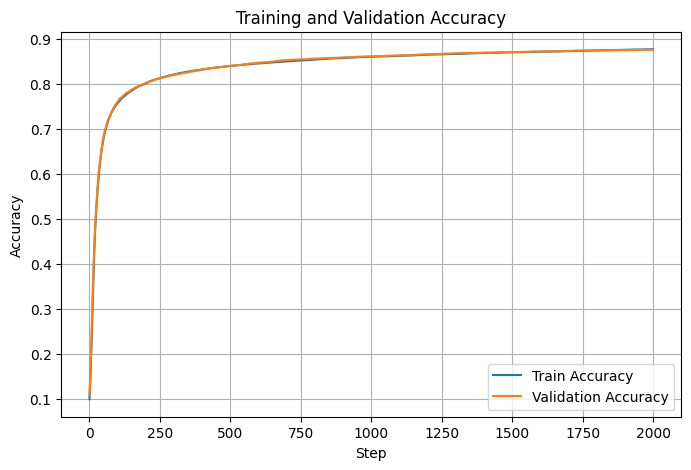

Test Accuracy: 87.59%

Accuracy for each class:
Digit 0: 95.00%
Digit 1: 96.19%
Digit 2: 83.26%
Digit 3: 85.92%
Digit 4: 88.06%
Digit 5: 75.30%
Digit 6: 93.60%
Digit 7: 89.31%
Digit 8: 81.98%
Digit 9: 84.97%


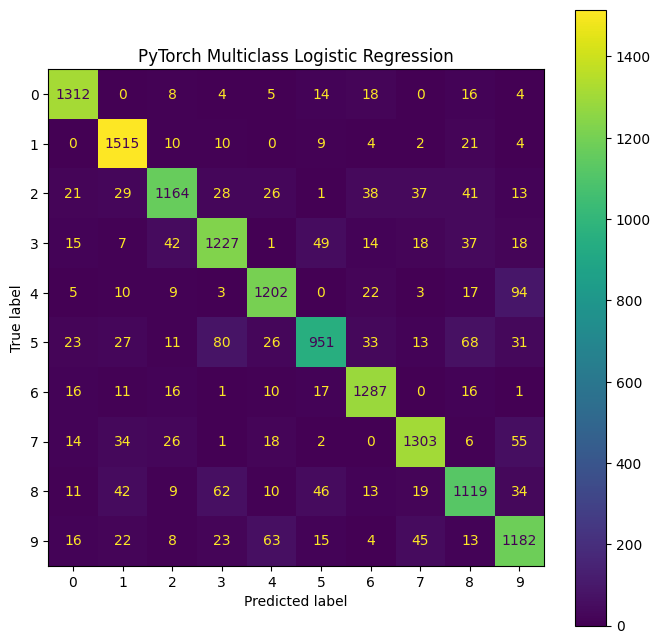

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# ==========================================
# 1. Multiclass Logistic Regression
# ==========================================

class MulticlassLogisticRegression(nn.Module):

    def __init__(self, input_features, num_classes):
        super().__init__()

        self.linear = nn.Linear(input_features,num_classes,bias=False)

    def forward(self, X):
        return self.linear(X)


# ==========================================
# 2. Create Model
# ==========================================

input_features = X_train.shape[1]
num_classes = 10

model = MulticlassLogisticRegression(input_features, num_classes)


# ==========================================
# 3. Loss & Optimizer
# ==========================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(),lr=0.01)


# ==========================================
# 4. Training
# ==========================================

steps = 2000
train_losses = []
val_losses = []
train_accs = []
val_accs = []


for step in range(steps):

    # Forward
    train_logits = model(X_train)

    # Loss
    train_loss = criterion( train_logits,y_train)

    # Backpropagation
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    # Validation
    with torch.no_grad():

        val_logits = model(X_val)
        val_loss = criterion(val_logits,y_val)

        train_preds = torch.argmax(train_logits,dim=1)

        val_preds = torch.argmax(val_logits,dim=1)

        train_acc = ( train_preds == y_train).float().mean()

        val_acc = (val_preds == y_val).float().mean()


    # Store results
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())
    train_accs.append(train_acc.item())
    val_accs.append(val_acc.item())
    # Print
    if (step + 1) % 250 == 0 or step == 0:

        print(f"step [{step+1}/{steps}] :\n"f"Train Loss: {train_loss:.4f} | "f"Val Loss: {val_loss:.4f} | " f"Val Acc: {val_acc*100:.2f}%\n")


# ==========================================
# 5. Plot Loss
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(train_losses,label="Train Loss")

plt.plot(val_losses,label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()


# ==========================================
# 6. Plot Accuracy
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(train_accs,label="Train Accuracy")
plt.plot(val_accs,label="Validation Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()


# ==========================================
# 7. Test
# ==========================================

with torch.no_grad():

    test_logits = model(X_test)

    test_preds = torch.argmax( test_logits, dim=1)

    test_acc = ( test_preds == y_test).float().mean()


print(f"Test Accuracy: " f"{test_acc * 100:.2f}%")


# ==========================================
# 8. Accuracy for Each Class
# ==========================================

print("\nAccuracy for each class:")

for class_id in range(10):

    mask = ( y_test == class_id)

    total = mask.sum()

    correct = (test_preds[mask] == y_test[mask]).sum()

    class_accuracy = (correct.float() / total.float())

    print(f"Digit {class_id}: "f"{class_accuracy * 100:.2f}%" )


# ==========================================
# 9. Confusion Matrix
# ==========================================

cm = confusion_matrix( y_test.numpy(),test_preds.numpy())

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        '0', '1', '2', '3', '4',
        '5', '6', '7', '8', '9'
    ]
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(ax=ax)

plt.title(
    "PyTorch Multiclass Logistic Regression"
)

plt.show()



In [6]:
# B1 - IMPORT LIBRARIES
import os
import time
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from torchvision import datasets

from sklearn.model_selection import train_test_split


In [7]:
# B1 - CONFIGURATION
SEED = 42


# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Select GPU if available, otherwise CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [8]:
# B1 - LOAD MNIST DATASET
# Download MNIST
mnist_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

# Convert images from uint8 [0,255] to float [0,1]
X_full = mnist_dataset.data.float() / 255.0

# Labels
y_full = mnist_dataset.targets

print("\nFull MNIST dataset:")
print("Images:", X_full.shape)
print("Labels:", y_full.shape)


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.95MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.82MB/s]



Full MNIST dataset:
Images: torch.Size([60000, 28, 28])
Labels: torch.Size([60000])


In [9]:
# B1 - STRATIFIED 60/20/20 TRAIN/VALIDATION/TEST SPLIT
# Convert labels to NumPy for sklearn
y_full_np = y_full.numpy()

# Create indices
all_indices = np.arange(len(X_full))

# First split:
# 60% training
# 40% temporary
train_indices, temp_indices = train_test_split(
    all_indices,
    test_size=0.40,
    stratify=y_full_np,
    random_state=SEED
)

# Second split:
# 20% validation
# 20% test
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    stratify=y_full_np[temp_indices],
    random_state=SEED
)

print("\nDataset split:")
print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Test samples:", len(test_indices))



Dataset split:
Training samples: 36000
Validation samples: 12000
Test samples: 12000


In [10]:
# B1 - CREATE TRAINING / VALIDATION / TEST SETS
X_train = X_full[train_indices]
y_train = y_full[train_indices]

X_val = X_full[val_indices]
y_val = y_full[val_indices]

X_test = X_full[test_indices]
y_test = y_full[test_indices]

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)



Shapes:
X_train: torch.Size([36000, 28, 28])
X_val: torch.Size([12000, 28, 28])
X_test: torch.Size([12000, 28, 28])


In [11]:
# B1 - CREATE PYTORCH DATASETS AND DATALOADERS
BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataLoaders:")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))



DataLoaders:
Training batches: 563
Validation batches: 188
Test batches: 188


In [12]:
# B1 - FLEXIBLE FEEDFORWARD NEURAL NETWORK
class FlexibleNeuralNetwork(nn.Module):

    def __init__(
        self,
        input_size=784,
        hidden_layers=[128, 128],
        output_size=10
    ):
        super().__init__()

        layers = []

        # Number of neurons entering the first layer
        previous_size = input_size

        # ----------------------------------------------------
        # Create hidden layers
        # ----------------------------------------------------

        for hidden_size in hidden_layers:

            # Fully connected layer
            layers.append(
                nn.Linear(
                    previous_size,
                    hidden_size
                )
            )

            # ReLU activation
            layers.append(
                nn.ReLU()
            )

            previous_size = hidden_size

        # ----------------------------------------------------
        # Output layer
        # ----------------------------------------------------

        layers.append(
            nn.Linear(
                previous_size,
                output_size
            )
        )

        # Combine layers
        self.network = nn.Sequential(*layers)

        # Initialize weights
        self.initialize_weights()


    # ========================================================
    # B1 - HE WEIGHT INITIALIZATION
    # ========================================================

    def initialize_weights(self):

        for layer in self.network:

            if isinstance(layer, nn.Linear):

                # He/Kaiming initialization
                # Appropriate for ReLU networks
                nn.init.kaiming_normal_(
                    layer.weight,
                    mode="fan_in",
                    nonlinearity="relu"
                )

                # Bias initialization
                nn.init.zeros_(
                    layer.bias
                )


    # ========================================================
    # B1 - FORWARD PASS
    # ========================================================

    def forward(self, x):

        # Flatten:
        # [batch_size, 28, 28]
        #
        # becomes:
        # [batch_size, 784]

        x = x.view(
            x.size(0),
            -1
        )

        return self.network(x)


In [13]:

# B1 - CREATE BASELINE MODEL

# Baseline architecture:
#
# 784 → 128 → 128 → 10

HIDDEN_LAYERS = [128, 128]

model = FlexibleNeuralNetwork(
    input_size=784,
    hidden_layers=HIDDEN_LAYERS,
    output_size=10
)

# Move model to CPU/GPU
model = model.to(device)

print("\nBaseline model:")
print(model)



Baseline model:
FlexibleNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [14]:
# B1 - COUNT TRAINABLE PARAMETERS

def count_parameters(model):

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


total_parameters = count_parameters(model)

print(
    "\nTrainable parameters:",
    total_parameters
)



Trainable parameters: 118282


In [15]:
# B2 - TRAINING CONFIGURATION
LEARNING_RATE = 0.01
EPOCHS = 20

# Cross-entropy loss
criterion = nn.CrossEntropyLoss()

# Stochastic Gradient Descent
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE
)

print("\nTraining configuration:")
print("Optimizer: SGD")
print("Learning rate:", LEARNING_RATE)
print("Batch size:", BATCH_SIZE)
print("Loss function: CrossEntropyLoss")
print("Epochs:", EPOCHS)



Training configuration:
Optimizer: SGD
Learning rate: 0.01
Batch size: 64
Loss function: CrossEntropyLoss
Epochs: 20


In [16]:
def evaluate_model(
    model,
    data_loader,
    criterion,
    device
):

    # Evaluation mode
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient calculation
    with torch.no_grad():

        for images, labels in data_loader:

            # Move data to CPU/GPU
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(
                outputs,
                labels
            )

            # Accumulate total loss
            total_loss += (
                loss.item() *
                images.size(0)
            )

            # Get predicted class
            predictions = torch.argmax(
                outputs,
                dim=1
            )

            # Count correct predictions
            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    # Average loss
    average_loss = total_loss / total

    # Accuracy
    accuracy = correct / total

    return average_loss, accuracy


In [17]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    device
):

    # Store training history
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "epoch_time": []
    }

    # Keep best model based on validation accuracy
    best_val_accuracy = 0.0

    best_model_state = copy.deepcopy(
        model.state_dict()
    )

    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(epochs):

        epoch_start = time.time()

        # ====================================================
        # TRAINING PHASE
        # ====================================================

        model.train()

        running_loss = 0.0

        correct = 0
        total = 0

        # ----------------------------------------------------
        # Mini-batch loop
        # ----------------------------------------------------

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # ------------------------------------------------
            # Clear old gradients
            # ------------------------------------------------

            optimizer.zero_grad()

            # ------------------------------------------------
            # Forward propagation
            # ------------------------------------------------

            outputs = model(images)

            # ------------------------------------------------
            # Calculate loss
            # ------------------------------------------------

            loss = criterion(
                outputs,
                labels
            )

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------

            loss.backward()

            # ------------------------------------------------
            # Update weights using SGD
            # ------------------------------------------------

            optimizer.step()

            # ------------------------------------------------
            # Calculate statistics
            # ------------------------------------------------

            running_loss += (
                loss.item() *
                images.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        # Average training loss
        train_loss = running_loss / total

        # Training accuracy
        train_accuracy = correct / total


        # ====================================================
        # VALIDATION PHASE
        # ====================================================

        val_loss, val_accuracy = evaluate_model(
            model,
            val_loader,
            criterion,
            device
        )


        # ====================================================
        # EPOCH TIME
        # ====================================================

        epoch_time = (
            time.time() -
            epoch_start
        )


        # ====================================================
        # STORE METRICS
        # ====================================================

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        history["epoch_time"].append(
            epoch_time
        )


        # ====================================================
        # SAVE BEST MODEL
        # ====================================================

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            best_model_state = copy.deepcopy(
                model.state_dict()
            )


        # ====================================================
        # PRINT PROGRESS
        # ====================================================

        print(
            f"Epoch [{epoch + 1:02d}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy * 100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy * 100:.2f}% | "
            f"Time: {epoch_time:.2f}s"
        )


    # ========================================================
    # LOAD BEST MODEL
    # ========================================================

    model.load_state_dict(
        best_model_state
    )

    return history


In [18]:
print("\n" + "=" * 70)
print("STARTING BASELINE TRAINING")
print("=" * 70)

training_start = time.time()

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device
)

total_training_time = (
    time.time() -
    training_start
)

print(
    "\nTotal training time:",
    f"{total_training_time:.2f} seconds"
)



STARTING BASELINE TRAINING
Epoch [01/20] | Train Loss: 0.9987 | Train Acc: 74.53% | Val Loss: 0.5008 | Val Acc: 86.23% | Time: 2.06s
Epoch [02/20] | Train Loss: 0.4127 | Train Acc: 88.76% | Val Loss: 0.3724 | Val Acc: 89.62% | Time: 1.29s
Epoch [03/20] | Train Loss: 0.3354 | Train Acc: 90.60% | Val Loss: 0.3290 | Val Acc: 90.48% | Time: 1.29s
Epoch [04/20] | Train Loss: 0.2979 | Train Acc: 91.55% | Val Loss: 0.2993 | Val Acc: 91.42% | Time: 1.31s
Epoch [05/20] | Train Loss: 0.2728 | Train Acc: 92.22% | Val Loss: 0.2783 | Val Acc: 92.05% | Time: 1.32s
Epoch [06/20] | Train Loss: 0.2532 | Train Acc: 92.80% | Val Loss: 0.2668 | Val Acc: 92.38% | Time: 1.33s
Epoch [07/20] | Train Loss: 0.2380 | Train Acc: 93.15% | Val Loss: 0.2500 | Val Acc: 92.73% | Time: 1.31s
Epoch [08/20] | Train Loss: 0.2245 | Train Acc: 93.56% | Val Loss: 0.2385 | Val Acc: 93.08% | Time: 1.28s
Epoch [09/20] | Train Loss: 0.2131 | Train Acc: 93.93% | Val Loss: 0.2286 | Val Acc: 93.44% | Time: 1.46s
Epoch [10/20] | Tr

In [19]:
# B3 - EXTRACT TRAINING HISTORY
epochs_range = np.arange(
    1,
    EPOCHS + 1
)


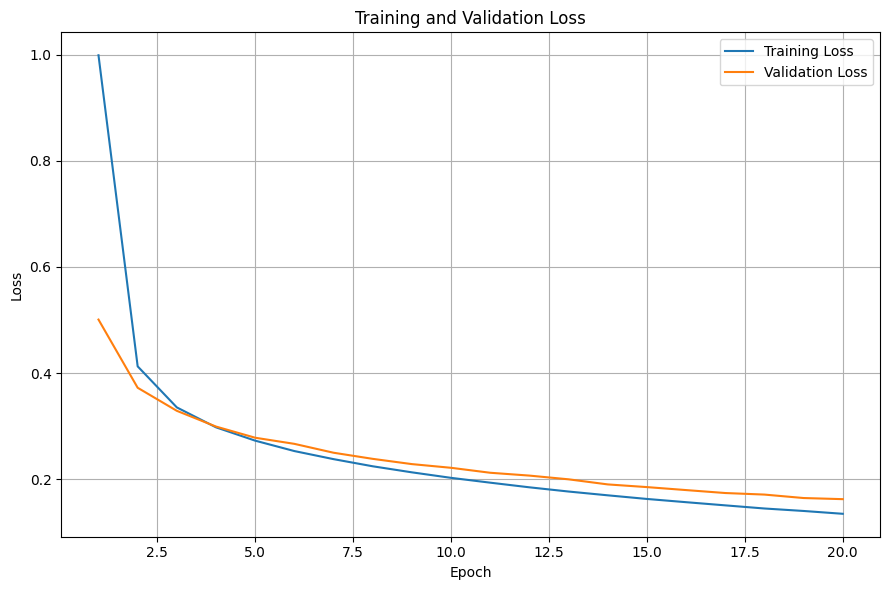

In [20]:
# B3 - PLOT TRAINING / VALIDATION LOSS
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


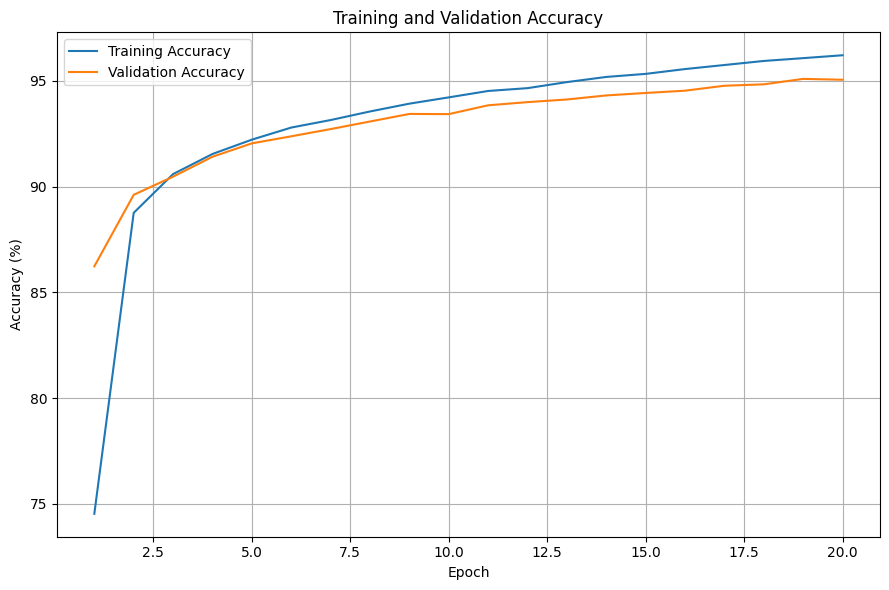

In [21]:
# B3 - PLOT TRAINING / VALIDATION ACCURACY
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    np.array(history["train_accuracy"]) * 100,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    np.array(history["val_accuracy"]) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [22]:
# B3 - FINAL PERFORMANCE
final_train_accuracy = (
    history["train_accuracy"][-1]
)

final_val_accuracy = (
    history["val_accuracy"][-1]
)

best_val_accuracy = max(
    history["val_accuracy"]
)

best_epoch = (
    np.argmax(
        history["val_accuracy"]
    ) + 1
)

print("\n" + "=" * 70)
print("BASELINE PERFORMANCE")
print("=" * 70)

print(
    f"Final Training Accuracy: "
    f"{final_train_accuracy * 100:.2f}%"
)

print(
    f"Final Validation Accuracy: "
    f"{final_val_accuracy * 100:.2f}%"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Best Epoch: {best_epoch}"
)



BASELINE PERFORMANCE
Final Training Accuracy: 96.22%
Final Validation Accuracy: 95.06%
Best Validation Accuracy: 95.10%
Best Epoch: 19


In [23]:
# B3 - TEST SET EVALUATION
test_loss, test_accuracy = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print("\nTest Results:")

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)



Test Results:
Test Loss: 0.1643
Test Accuracy: 95.24%


In [24]:
# B3 - CONVERGENCE ANALYSIS
print("\n" + "=" * 70)
print("CONVERGENCE ANALYSIS")
print("=" * 70)

print(
    f"Best validation accuracy was reached "
    f"at epoch {best_epoch}."
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print("\nLast five training losses:")

for loss in history["train_loss"][-5:]:

    print(
        f"{loss:.6f}"
    )

print("\nLast five validation losses:")

for loss in history["val_loss"][-5:]:

    print(
        f"{loss:.6f}"
    )



CONVERGENCE ANALYSIS
Best validation accuracy was reached at epoch 19.
Best validation accuracy: 95.10%

Last five training losses:
0.156872
0.150903
0.145001
0.140330
0.135016

Last five validation losses:
0.179684
0.174134
0.171210
0.164700
0.162586


In [25]:
# B3 - MULTIPLE RUNS FOR LEARNING CURVES + ERROR BARS
# Running the same experiment multiple times allows us
# to calculate mean and standard deviation.

NUM_RUNS = 5

SEEDS = [
    42,
    43,
    44,
    45,
    46
]


In [26]:
# B3 - FUNCTION FOR REPEATED EXPERIMENT
def run_experiment(
    seed,
    hidden_layers=[128, 128],
    learning_rate=0.01,
    batch_size=64,
    epochs=20
):

    # --------------------------------------------------------
    # Set random seed
    # --------------------------------------------------------

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)


    # --------------------------------------------------------
    # Create DataLoaders
    # --------------------------------------------------------

    train_loader_exp = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader_exp = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )


    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------

    model_exp = FlexibleNeuralNetwork(
        input_size=784,
        hidden_layers=hidden_layers,
        output_size=10
    ).to(device)


    # --------------------------------------------------------
    # Loss function
    # --------------------------------------------------------

    criterion_exp = nn.CrossEntropyLoss()


    # --------------------------------------------------------
    # SGD optimizer
    # --------------------------------------------------------

    optimizer_exp = torch.optim.SGD(
        model_exp.parameters(),
        lr=learning_rate
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history_exp = train_model(
        model=model_exp,
        train_loader=train_loader_exp,
        val_loader=val_loader_exp,
        criterion=criterion_exp,
        optimizer=optimizer_exp,
        epochs=epochs,
        device=device
    )

    return history_exp


In [27]:
# B3 - RUN REPEATED EXPERIMENTS
print("\n" + "=" * 70)
print("STARTING REPEATED EXPERIMENTS")
print("=" * 70)

all_histories = []

for seed in SEEDS:

    print("\n" + "-" * 70)
    print(f"Experiment with random seed: {seed}")
    print("-" * 70)

    history_exp = run_experiment(
        seed=seed,
        hidden_layers=[128, 128],
        learning_rate=0.01,
        batch_size=64,
        epochs=20
    )

    all_histories.append(
        history_exp
    )



STARTING REPEATED EXPERIMENTS

----------------------------------------------------------------------
Experiment with random seed: 42
----------------------------------------------------------------------
Epoch [01/20] | Train Loss: 0.9987 | Train Acc: 74.53% | Val Loss: 0.5008 | Val Acc: 86.23% | Time: 1.25s
Epoch [02/20] | Train Loss: 0.4127 | Train Acc: 88.76% | Val Loss: 0.3724 | Val Acc: 89.62% | Time: 1.27s
Epoch [03/20] | Train Loss: 0.3354 | Train Acc: 90.60% | Val Loss: 0.3290 | Val Acc: 90.48% | Time: 1.27s
Epoch [04/20] | Train Loss: 0.2979 | Train Acc: 91.55% | Val Loss: 0.2993 | Val Acc: 91.42% | Time: 1.30s
Epoch [05/20] | Train Loss: 0.2728 | Train Acc: 92.22% | Val Loss: 0.2783 | Val Acc: 92.05% | Time: 1.25s
Epoch [06/20] | Train Loss: 0.2532 | Train Acc: 92.80% | Val Loss: 0.2668 | Val Acc: 92.38% | Time: 1.31s
Epoch [07/20] | Train Loss: 0.2380 | Train Acc: 93.15% | Val Loss: 0.2500 | Val Acc: 92.73% | Time: 1.47s
Epoch [08/20] | Train Loss: 0.2245 | Train Acc: 93.5

In [28]:
# B3 - CONVERT RESULTS TO NUMPY ARRAYS
train_accuracy_array = np.array([
    h["train_accuracy"]
    for h in all_histories
])

val_accuracy_array = np.array([
    h["val_accuracy"]
    for h in all_histories
])

train_loss_array = np.array([
    h["train_loss"]
    for h in all_histories
])

val_loss_array = np.array([
    h["val_loss"]
    for h in all_histories
])


In [29]:
# B3 - CALCULATE MEAN AND STANDARD DEVIATION
mean_train_accuracy = (
    train_accuracy_array.mean(axis=0)
)

std_train_accuracy = (
    train_accuracy_array.std(axis=0)
)

mean_val_accuracy = (
    val_accuracy_array.mean(axis=0)
)

std_val_accuracy = (
    val_accuracy_array.std(axis=0)
)

mean_train_loss = (
    train_loss_array.mean(axis=0)
)

std_train_loss = (
    train_loss_array.std(axis=0)
)

mean_val_loss = (
    val_loss_array.mean(axis=0)
)

std_val_loss = (
    val_loss_array.std(axis=0)
)


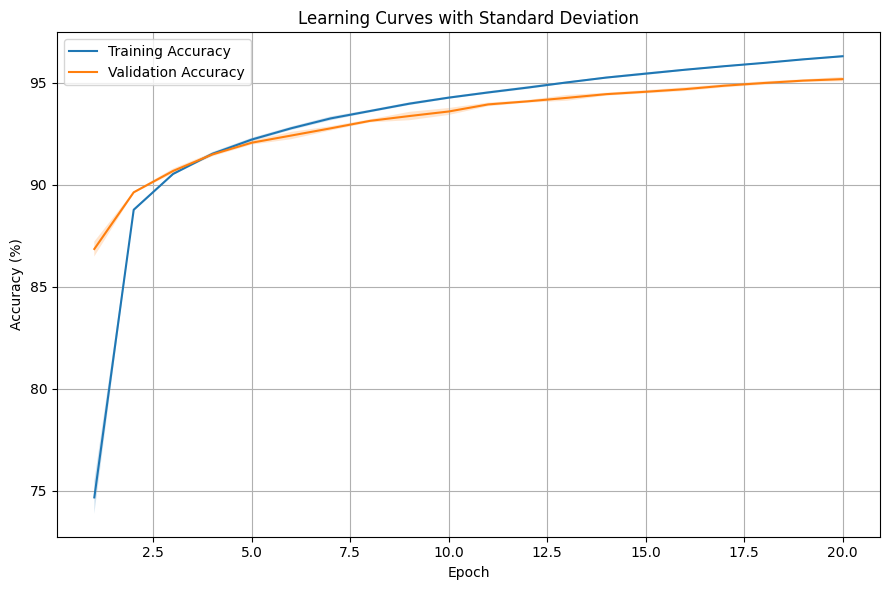

In [30]:
# B3 - LEARNING CURVE WITH ERROR BARS - ACCURACY
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    mean_train_accuracy * 100,
    label="Training Accuracy"
)

plt.fill_between(
    epochs_range,
    (mean_train_accuracy - std_train_accuracy) * 100,
    (mean_train_accuracy + std_train_accuracy) * 100,
    alpha=0.2
)

plt.plot(
    epochs_range,
    mean_val_accuracy * 100,
    label="Validation Accuracy"
)

plt.fill_between(
    epochs_range,
    (mean_val_accuracy - std_val_accuracy) * 100,
    (mean_val_accuracy + std_val_accuracy) * 100,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Learning Curves with Standard Deviation"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


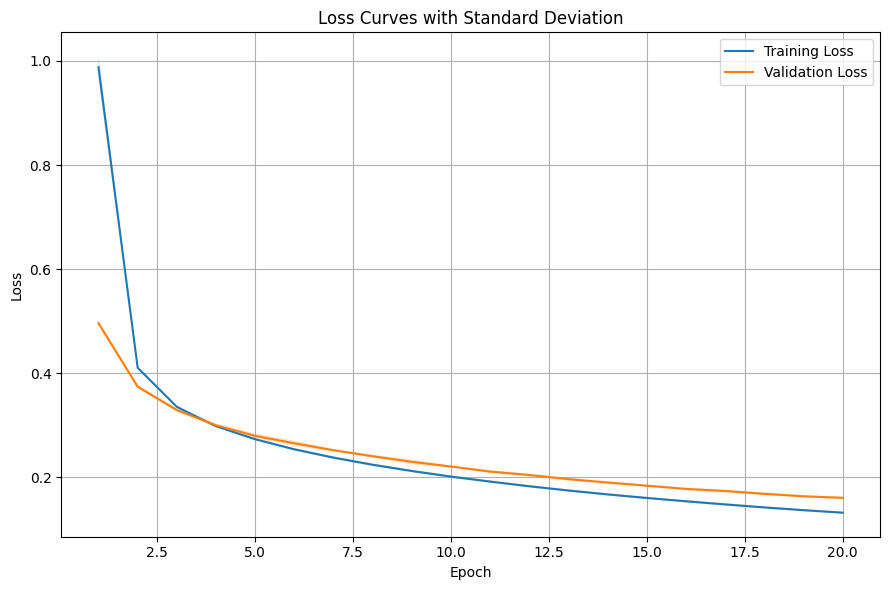

In [31]:
# B3 - LEARNING CURVE WITH ERROR BARS - LOSS
plt.figure(figsize=(9, 6))

plt.plot(
    epochs_range,
    mean_train_loss,
    label="Training Loss"
)

plt.fill_between(
    epochs_range,
    mean_train_loss - std_train_loss,
    mean_train_loss + std_train_loss,
    alpha=0.2
)

plt.plot(
    epochs_range,
    mean_val_loss,
    label="Validation Loss"
)

plt.fill_between(
    epochs_range,
    mean_val_loss - std_val_loss,
    mean_val_loss + std_val_loss,
    alpha=0.2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Loss Curves with Standard Deviation"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [32]:
# B3 - REPEATED EXPERIMENT SUMMARY
final_train_accuracies = [
    h["train_accuracy"][-1]
    for h in all_histories
]

final_val_accuracies = [
    h["val_accuracy"][-1]
    for h in all_histories
]

print("\n" + "=" * 70)
print("REPEATED EXPERIMENT RESULTS")
print("=" * 70)

print(
    f"Training Accuracy: "
    f"{np.mean(final_train_accuracies) * 100:.2f}% "
    f"+/- "
    f"{np.std(final_train_accuracies) * 100:.2f}%"
)

print(
    f"Validation Accuracy: "
    f"{np.mean(final_val_accuracies) * 100:.2f}% "
    f"+/- "
    f"{np.std(final_val_accuracies) * 100:.2f}%"
)



REPEATED EXPERIMENT RESULTS
Training Accuracy: 96.31% +/- 0.05%
Validation Accuracy: 95.18% +/- 0.11%


In [33]:
# B3 - SAVE BASELINE MODEL CHECKPOINT
os.makedirs(
    "checkpoints",
    exist_ok=True
)

checkpoint = {

    "model_state_dict":
        model.state_dict(),

    "architecture":
        HIDDEN_LAYERS,

    "input_size":
        784,

    "output_size":
        10,

    "learning_rate":
        LEARNING_RATE,

    "batch_size":
        BATCH_SIZE,

    "epochs":
        EPOCHS,

    "test_accuracy":
        test_accuracy,

    "best_validation_accuracy":
        best_val_accuracy
}

torch.save(
    checkpoint,
    "checkpoints/baseline_nn.pth"
)

print(
    "\nModel checkpoint saved to:"
)

print(
    "checkpoints/baseline_nn.pth"
)



Model checkpoint saved to:
checkpoints/baseline_nn.pth


In [34]:
# B3 - VISUALIZE MODEL PREDICTIONS
def show_predictions(
    model,
    data_loader,
    device,
    num_images=12
):

    model.eval()

    images_list = []
    labels_list = []
    predictions_list = []

    with torch.no_grad():

        for images, labels in data_loader:

            images_device = images.to(
                device
            )

            outputs = model(
                images_device
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            images_list.extend(
                images
            )

            labels_list.extend(
                labels
            )

            predictions_list.extend(
                predictions.cpu()
            )

            if len(images_list) >= num_images:

                break


    # --------------------------------------------------------
    # Plot images
    # --------------------------------------------------------

    plt.figure(
        figsize=(12, 8)
    )

    for i in range(num_images):

        image = images_list[i].squeeze()

        true_label = (
            labels_list[i].item()
        )

        predicted_label = (
            predictions_list[i].item()
        )

        plt.subplot(
            3,
            4,
            i + 1
        )

        plt.imshow(
            image,
            cmap="gray"
        )

        plt.title(
            f"True: {true_label} | "
            f"Predicted: {predicted_label}"
        )

        plt.axis("off")

    plt.tight_layout()

    plt.show()


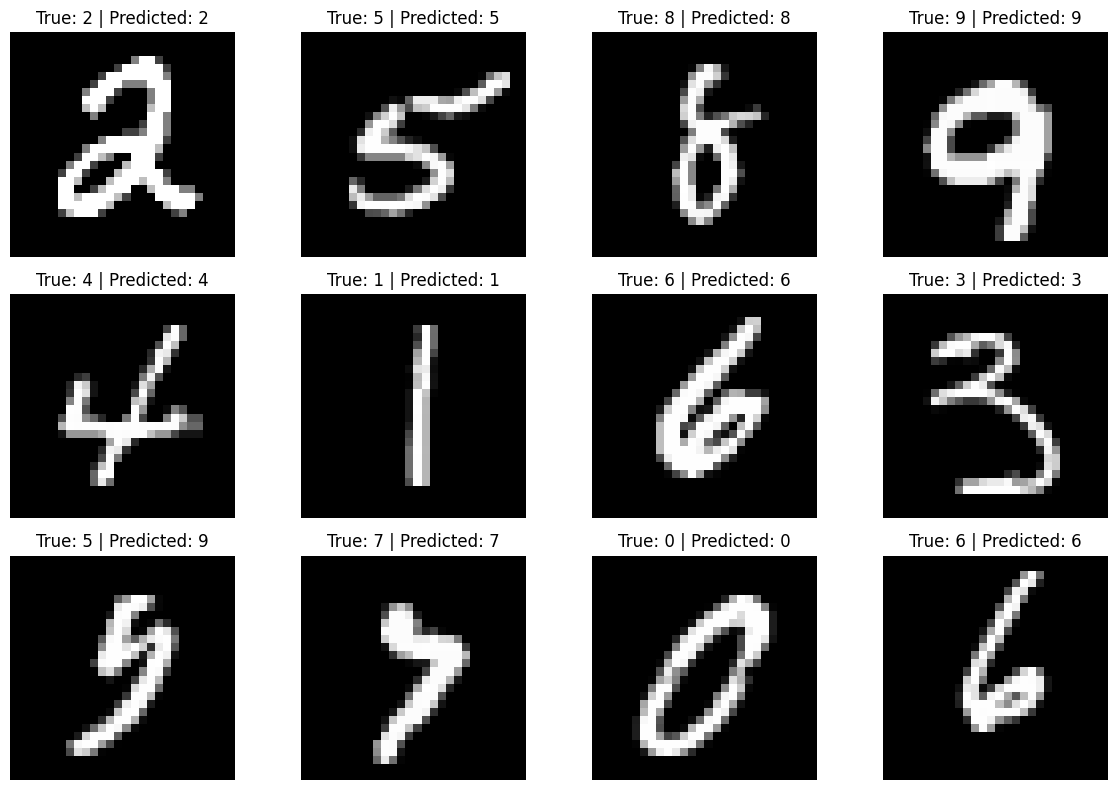

In [35]:
# B3 - DISPLAY PREDICTIONS
show_predictions(
    model=model,
    data_loader=test_loader,
    device=device,
    num_images=12
)


In [36]:
# B1 - FINAL ARCHITECTURE SUMMARY
print("\n" + "=" * 70)
print("FINAL MODEL ARCHITECTURE")
print("=" * 70)

print("Input: 784 features")

for i, neurons in enumerate(
    HIDDEN_LAYERS
):

    print(
        f"Hidden Layer {i + 1}: "
        f"{neurons} neurons + ReLU"
    )

print("Output: 10 classes")

print(
    "\nTotal trainable parameters:",
    total_parameters
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Test accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print("\nPart B completed.")



FINAL MODEL ARCHITECTURE
Input: 784 features
Hidden Layer 1: 128 neurons + ReLU
Hidden Layer 2: 128 neurons + ReLU
Output: 10 classes

Total trainable parameters: 118282
Best validation accuracy: 95.10%
Test accuracy: 95.24%

Part B completed.


Imports completed successfully!
Device: cuda
GPU: Tesla T4
MNIST loaded successfully!
Total samples: 60000

Data split:
Train: 36000
Validation: 12000
Test: 12000

TEST MODE:
Train samples: 36000
Validation samples: 12000

LEARNING RATE EXPERIMENT

Testing Learning Rate = 0.001
Epoch 1/3 | Train Loss: 2.2385 | Train Acc: 0.1982 | Val Loss: 2.1028 | Val Acc: 0.3615 | Time: 7.92s
Epoch 2/3 | Train Loss: 1.9518 | Train Acc: 0.5022 | Val Loss: 1.7894 | Val Acc: 0.6088 | Time: 6.24s
Epoch 3/3 | Train Loss: 1.6052 | Train Acc: 0.6839 | Val Loss: 1.4322 | Val Acc: 0.7249 | Time: 7.10s

Testing Learning Rate = 0.01
Epoch 1/3 | Train Loss: 1.1427 | Train Acc: 0.7156 | Val Loss: 0.5663 | Val Acc: 0.8564 | Time: 6.26s
Epoch 2/3 | Train Loss: 0.4566 | Train Acc: 0.8778 | Val Loss: 0.4021 | Val Acc: 0.8907 | Time: 6.98s
Epoch 3/3 | Train Loss: 0.3618 | Train Acc: 0.8980 | Val Loss: 0.3488 | Val Acc: 0.9022 | Time: 6.30s

Testing Learning Rate = 0.1
Epoch 1/3 | Train Loss: 0.4308 | Train Acc: 0.8756

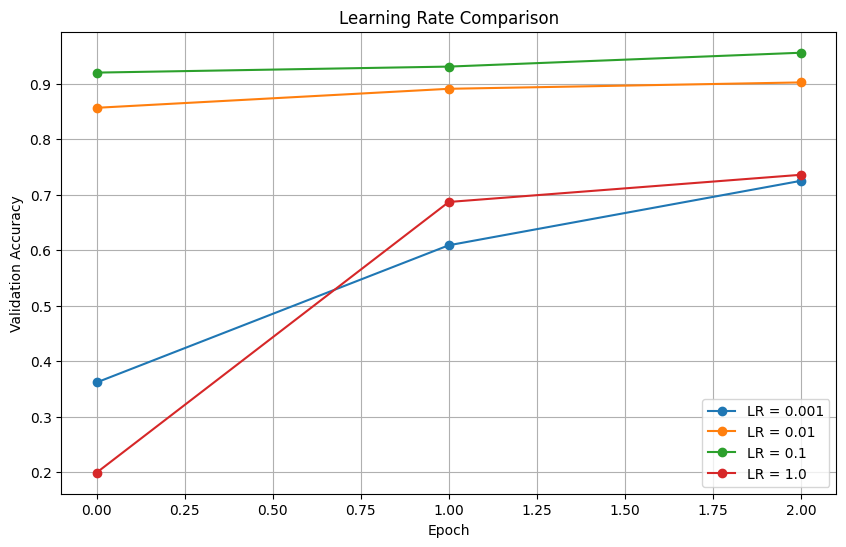


FINAL LEARNING RATE RESULTS
Learning Rate 0.001: Final Validation Accuracy = 0.7249
Learning Rate 0.01: Final Validation Accuracy = 0.9022
Learning Rate 0.1: Final Validation Accuracy = 0.9557
Learning Rate 1.0: Final Validation Accuracy = 0.7358
Best Learning Rate: 0.1


In [51]:
# ============================================================
# ASSIGNMENT 2 - PART C1
# Hyperparameter Analysis - FIRST TEST
# ============================================================

# -------------------------
# 1. Imports
# -------------------------
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

print("Imports completed successfully!")


# -------------------------
# 2. Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# -------------------------
# 3. Load MNIST
# -------------------------
transform = transforms.ToTensor()

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

print("MNIST loaded successfully!")
print("Total samples:", len(dataset))


# -------------------------
# 4. Get labels
# -------------------------
labels = np.array(dataset.targets)

indices = np.arange(len(dataset))


# -------------------------
# 5. Stratified split
#    60% Train
#    20% Validation
#    20% Test
# -------------------------

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.40,
    stratify=labels,
    random_state=42
)

temp_labels = labels[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

print("\nData split:")
print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))


# -------------------------
# 6. Create datasets
# -------------------------
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)


# ============================================================
# TEST VERSION
# We use a smaller subset first just to make sure everything
# works correctly.
# ============================================================

# TEST_TRAIN_SIZE = 6000
# TEST_VAL_SIZE = 2000

#train_dataset = Subset(train_dataset, range(TEST_TRAIN_SIZE))
#val_dataset = Subset(val_dataset, range(TEST_VAL_SIZE))

print("\nTEST MODE:")
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


# -------------------------
# 7. Flexible Neural Network
# -------------------------
class FlexibleNN(nn.Module):

    def __init__(self, hidden_layers=[128, 64]):

        super().__init__()

        layers = []

        input_size = 28 * 28

        for hidden_size in hidden_layers:

            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())

            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))

        self.network = nn.Sequential(*layers)

        # Xavier Initialization
        for layer in self.network:

            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)


    def forward(self, x):

        # 28x28 -> 784
        x = x.view(x.size(0), -1)

        return self.network(x)


# -------------------------
# 8. Training Function
# -------------------------
def train_model(
    learning_rate,
    batch_size,
    epochs=3,
    hidden_layers=[128, 64]
):

    import time

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    model = FlexibleNN(
        hidden_layers=hidden_layers
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    epoch_times = []

    # Store gradient norms for gradient-noise analysis
    gradient_norms_per_epoch = []

    total_start_time = time.perf_counter()

    # -------------------------
    # Training Loop
    # -------------------------
    for epoch in range(epochs):

        epoch_start_time = time.perf_counter()

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        batch_gradient_norms = []

        for images, labels_batch in train_loader:

            images = images.to(device)
            labels_batch = labels_batch.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels_batch
            )

            loss.backward()

            # -------------------------
            # Gradient Norm
            # -------------------------
            total_gradient_norm = 0.0

            for parameter in model.parameters():

                if parameter.grad is not None:

                    total_gradient_norm += (
                        parameter.grad.detach()
                        .norm(2)
                        .item() ** 2
                    )

            total_gradient_norm = (
                total_gradient_norm ** 0.5
            )

            batch_gradient_norms.append(
                total_gradient_norm
            )

            # -------------------------
            # Update Parameters
            # -------------------------
            optimizer.step()

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels_batch
            ).sum().item()

            total += labels_batch.size(0)

        train_loss = (
            total_loss / len(train_loader)
        )

        train_accuracy = correct / total

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels_batch in val_loader:

                images = images.to(device)
                labels_batch = labels_batch.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels_batch
                )

                val_loss_total += loss.item()

                predictions = outputs.argmax(dim=1)

                val_correct += (
                    predictions == labels_batch
                ).sum().item()

                val_total += labels_batch.size(0)

        val_loss = (
            val_loss_total / len(val_loader)
        )

        val_accuracy = (
            val_correct / val_total
        )

        # -------------------------
        # Save Metrics
        # -------------------------
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(
            train_accuracy
        )

        val_accuracies.append(
            val_accuracy
        )

        epoch_time = (
            time.perf_counter()
            - epoch_start_time
        )

        epoch_times.append(epoch_time)

        gradient_norms_per_epoch.append(
            batch_gradient_norms
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

    total_training_time = (
        time.perf_counter()
        - total_start_time
    )

    return {

        "model": model,

        "train_losses": train_losses,

        "val_losses": val_losses,

        "train_accuracies":
            train_accuracies,

        "val_accuracies":
            val_accuracies,

        "epoch_times":
            epoch_times,

        "total_training_time":
            total_training_time,

        "gradient_norms":
            gradient_norms_per_epoch
    }

# ============================================================
# 9. C1 - LEARNING RATE TEST
# ============================================================

learning_rates = [0.001, 0.01, 0.1, 1.0]

results = {}

print("\n==============================")
print("LEARNING RATE EXPERIMENT")
print("==============================")


for lr in learning_rates:

    print(f"\nTesting Learning Rate = {lr}")

    results[lr] = train_model(
        learning_rate=lr,
        batch_size=64,
        epochs=3
    )


# ============================================================
# 10. Plot Validation Accuracy
# ============================================================

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    plt.plot(
        results[lr]["val_accuracies"],
        marker="o",
        label=f"LR = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 11. Print Final Results
# ============================================================

print("\n==============================")
print("FINAL LEARNING RATE RESULTS")
print("==============================")

for lr in learning_rates:

    final_accuracy = results[lr]["val_accuracies"][-1]

    print(
        f"Learning Rate {lr}: "
        f"Final Validation Accuracy = "
        f"{final_accuracy:.4f}"
    )
best_lr = max(

    results,

    key=lambda lr:
        results[lr]
        ["val_accuracies"][-1]
)


print(
    "Best Learning Rate:",
    best_lr
)


In [52]:
# ============================================================
# C1 - LEARNING RATE
# Convergence Speed and Stability Analysis
# ============================================================

print("\n" + "=" * 70)
print("LEARNING RATE - CONVERGENCE SPEED AND STABILITY")
print("=" * 70)


lr_analysis = []

for lr in learning_rates:

    val_acc = np.array(
        results[lr]["val_accuracies"]
    )

    val_loss = np.array(
        results[lr]["val_losses"]
    )

    # --------------------------------
    # Convergence Speed
    # --------------------------------
    # Epoch where validation accuracy
    # first reaches 90%
    convergence_epoch = None

    for epoch, accuracy in enumerate(
        val_acc,
        start=1
    ):

        if accuracy >= 0.90:

            convergence_epoch = epoch
            break

    # If 90% was never reached
    if convergence_epoch is None:

        convergence_epoch = np.nan


    # --------------------------------
    # Stability
    # --------------------------------
    # Standard deviation of validation
    # accuracy across epochs
    accuracy_std = np.std(val_acc)

    # Average absolute change between
    # consecutive validation accuracies
    mean_accuracy_change = np.mean(
        np.abs(np.diff(val_acc))
    )

    # --------------------------------
    # Best Epoch
    # --------------------------------
    best_epoch = (
        np.argmax(val_acc) + 1
    )

    best_accuracy = np.max(val_acc)

    final_accuracy = val_acc[-1]


    lr_analysis.append({

        "Learning Rate": lr,

        "Final Val Accuracy":
            final_accuracy,

        "Best Val Accuracy":
            best_accuracy,

        "Best Epoch":
            best_epoch,

        "Convergence Epoch (>=90%)":
            convergence_epoch,

        "Val Accuracy Std":
            accuracy_std,

        "Mean Epoch-to-Epoch Change":
            mean_accuracy_change,

        "Total Training Time (s)":
            results[lr][
                "total_training_time"
            ]
    })


lr_analysis_df = pd.DataFrame(
    lr_analysis
)


print("\nLearning Rate Analysis Table:\n")

display(
    lr_analysis_df.round(4)
)


LEARNING RATE - CONVERGENCE SPEED AND STABILITY

Learning Rate Analysis Table:



,Learning Rate,Final Val Accuracy,Best Val Accuracy,Best Epoch,Convergence Epoch (>=90%),Val Accuracy Std,Mean Epoch-to-Epoch Change,Total Training Time (s)
0,0.001,0.7249,0.7249,3,NaN,0.1515,0.1817,21.2714
1,0.010,0.9022,0.9022,3,3.0,0.0194,0.0229,19.5328
2,0.100,0.9557,0.9557,3,1.0,0.0150,0.0179,20.4397
3,1.000,0.7358,0.7358,3,NaN,0.2423,0.2684,20.1753


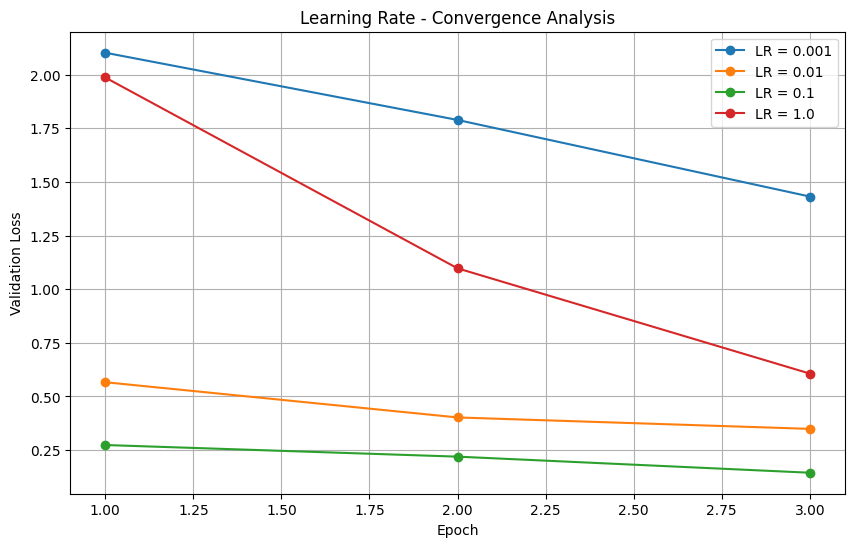

In [53]:
# ============================================================
# C1 - LEARNING RATE
# Convergence Speed
# ============================================================

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    plt.plot(
        range(
            1,
            len(
                results[lr]["val_losses"]
            ) + 1
        ),

        results[lr]["val_losses"],

        marker="o",

        label=f"LR = {lr}"
    )


plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title(
    "Learning Rate - Convergence Analysis"
)

plt.legend()

plt.grid()

plt.show()

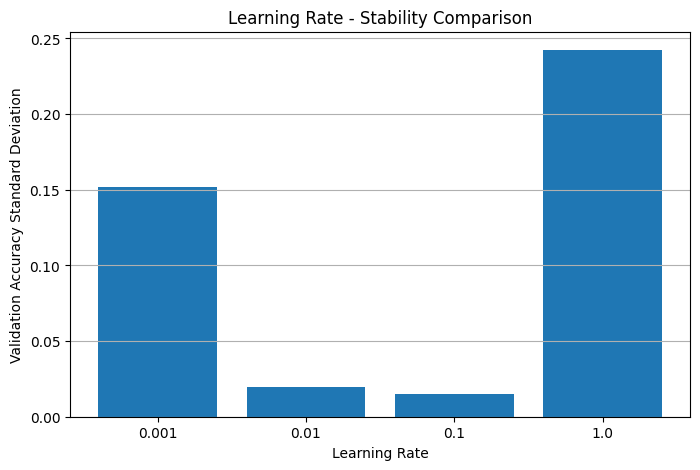

In [54]:
# ============================================================
# C1 - LEARNING RATE
# Stability Analysis
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    lr_analysis_df["Learning Rate"].astype(str),
    lr_analysis_df["Val Accuracy Std"]
)

plt.xlabel("Learning Rate")

plt.ylabel(
    "Validation Accuracy Standard Deviation"
)

plt.title(
    "Learning Rate - Stability Comparison"
)

plt.grid(
    axis="y"
)

plt.show()


Training with Batch Size = 16
Epoch 1/3 | Train Loss: 0.5914 | Train Acc: 0.8453 | Val Loss: 0.3327 | Val Acc: 0.9013 | Time: 10.61s
Epoch 2/3 | Train Loss: 0.2775 | Train Acc: 0.9201 | Val Loss: 0.2611 | Val Acc: 0.9257 | Time: 10.30s
Epoch 3/3 | Train Loss: 0.2264 | Train Acc: 0.9346 | Val Loss: 0.2272 | Val Acc: 0.9343 | Time: 10.40s

Training with Batch Size = 32
Epoch 1/3 | Train Loss: 0.8311 | Train Acc: 0.7793 | Val Loss: 0.4274 | Val Acc: 0.8809 | Time: 8.16s
Epoch 2/3 | Train Loss: 0.3539 | Train Acc: 0.8999 | Val Loss: 0.3328 | Val Acc: 0.9070 | Time: 7.41s
Epoch 3/3 | Train Loss: 0.2942 | Train Acc: 0.9155 | Val Loss: 0.2864 | Val Acc: 0.9196 | Time: 8.10s

Training with Batch Size = 64
Epoch 1/3 | Train Loss: 1.1802 | Train Acc: 0.7030 | Val Loss: 0.5776 | Val Acc: 0.8549 | Time: 6.79s
Epoch 2/3 | Train Loss: 0.4581 | Train Acc: 0.8787 | Val Loss: 0.4077 | Val Acc: 0.8860 | Time: 6.63s
Epoch 3/3 | Train Loss: 0.3599 | Train Acc: 0.8981 | Val Loss: 0.3470 | Val Acc: 0.9025 

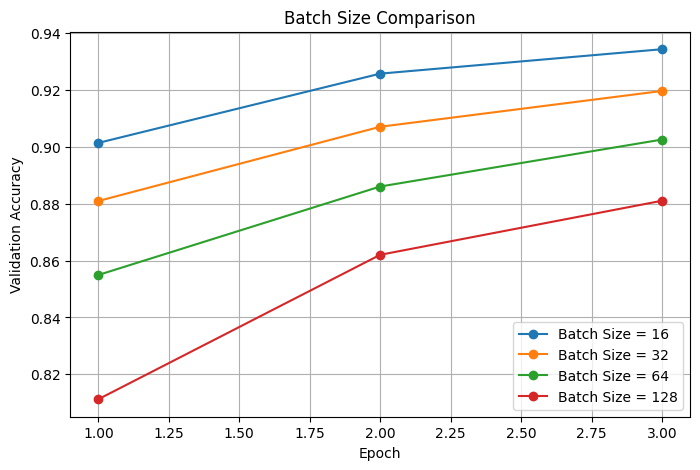

In [55]:
# ============================================================
# C1 - BATCH SIZE ANALYSIS
# ============================================================

batch_sizes = [16, 32, 64, 128]

batch_results = {}

for bs in batch_sizes:

    print(
        f"\nTraining with Batch Size = {bs}"
    )

    batch_results[bs] = train_model(

        learning_rate=0.01,

        batch_size=bs,

        epochs=3
    )


print(
    "\nFinal Validation Accuracies:"
)

for bs in batch_sizes:

    final_acc = (
        batch_results[bs]
        ["val_accuracies"][-1]
    )

    print(
        f"Batch Size {bs}: "
        f"{final_acc:.4f}"
    )
# -------------------------
# Best Batch Size
# -------------------------

best_bs = max(

    batch_results,

    key=lambda bs:
        batch_results[bs]
        ["val_accuracies"][-1]
)


print(
    "Best Batch Size:",
    best_bs
)

# ============================================================
# Validation Accuracy Plot
# ============================================================

plt.figure(figsize=(8, 5))

for bs in batch_sizes:

    plt.plot(

        range(
            1,
            len(
                batch_results[bs]
                ["val_accuracies"]
            ) + 1
        ),

        batch_results[bs]
        ["val_accuracies"],

        marker="o",

        label=f"Batch Size = {bs}"
    )


plt.xlabel("Epoch")

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Batch Size Comparison"
)

plt.legend()

plt.grid()

plt.show()

In [56]:
# ============================================================
# C1 - BATCH SIZE
# Training Efficiency and Final Performance
# ============================================================

batch_analysis = []

for bs in batch_sizes:

    result = batch_results[bs]

    final_val_accuracy = (
        result["val_accuracies"][-1]
    )

    total_time = (
        result["total_training_time"]
    )

    avg_epoch_time = np.mean(
        result["epoch_times"]
    )

    num_batches_per_epoch = int(
        np.ceil(
            len(train_dataset) / bs
        )
    )

    samples_per_second = (
        len(train_dataset) * 3
    ) / total_time


    batch_analysis.append({

        "Batch Size": bs,

        "Final Val Accuracy":
            final_val_accuracy,

        "Total Training Time (s)":
            total_time,

        "Average Epoch Time (s)":
            avg_epoch_time,

        "Batches per Epoch":
            num_batches_per_epoch,

        "Samples / Second":
            samples_per_second
    })


batch_analysis_df = pd.DataFrame(
    batch_analysis
)


print(
    "\nBatch Size Efficiency Analysis:\n"
)

display(
    batch_analysis_df.round(4)
)


Batch Size Efficiency Analysis:



,Batch Size,Final Val Accuracy,Total Training Time (s),Average Epoch Time (s),Batches per Epoch,Samples / Second
0,16,0.9342,31.3065,10.4354,2250,3449.7586
1,32,0.9196,23.6628,7.8875,1125,4564.1317
2,64,0.9025,20.4012,6.8003,563,5293.8058
3,128,0.8810,17.5517,5.8504,282,6153.2608


In [57]:
# ============================================================
# C1 - BATCH SIZE
# Gradient Noise Analysis
# ============================================================

gradient_noise_analysis = []

for bs in batch_sizes:

    result = batch_results[bs]

    # Combine all gradient norms
    # from all epochs
    all_gradient_norms = np.concatenate(
        result["gradient_norms"]
    )

    gradient_mean = np.mean(
        all_gradient_norms
    )

    gradient_std = np.std(
        all_gradient_norms
    )

    gradient_cv = (
        gradient_std / gradient_mean
        if gradient_mean != 0
        else 0
    )


    gradient_noise_analysis.append({

        "Batch Size": bs,

        "Mean Gradient Norm":
            gradient_mean,

        "Gradient Norm Std":
            gradient_std,

        "Gradient Noise (CV)":
            gradient_cv
    })


gradient_noise_df = pd.DataFrame(
    gradient_noise_analysis
)


print(
    "\nGradient Noise Analysis:\n"
)

display(
    gradient_noise_df.round(6)
)


Gradient Noise Analysis:



,Batch Size,Mean Gradient Norm,Gradient Norm Std,Gradient Noise (CV)
0,16,2.300628,0.972522,0.422720
1,32,1.796870,0.494110,0.274984
2,64,1.302115,0.249309,0.191465
3,128,0.979636,0.148994,0.152091


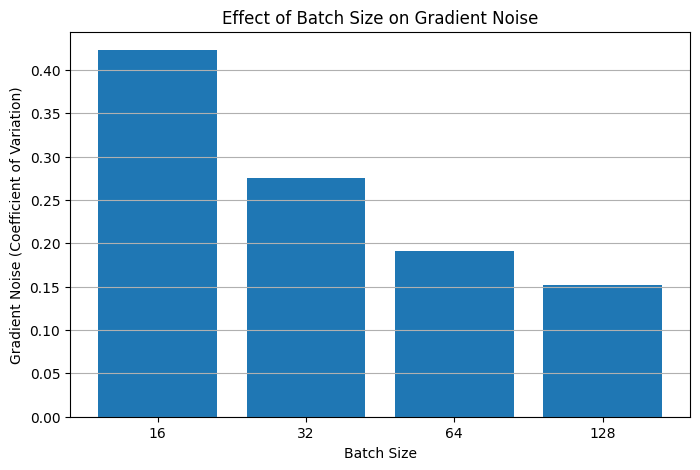

In [58]:
# ============================================================
# C1 - BATCH SIZE
# Gradient Noise Comparison
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(

    gradient_noise_df[
        "Batch Size"
    ].astype(str),

    gradient_noise_df[
        "Gradient Noise (CV)"
    ]
)

plt.xlabel(
    "Batch Size"
)

plt.ylabel(
    "Gradient Noise (Coefficient of Variation)"
)

plt.title(
    "Effect of Batch Size on Gradient Noise"
)

plt.grid(
    axis="y"
)

plt.show()


Training with 2 Hidden Layers: [128, 64]
Epoch 1/3 | Train Loss: 1.2322 | Train Acc: 0.6819 | Val Loss: 0.6041 | Val Acc: 0.8504 | Time: 7.00s
Epoch 2/3 | Train Loss: 0.4780 | Train Acc: 0.8725 | Val Loss: 0.4140 | Val Acc: 0.8880 | Time: 6.09s
Epoch 3/3 | Train Loss: 0.3714 | Train Acc: 0.8945 | Val Loss: 0.3567 | Val Acc: 0.8984 | Time: 6.84s

Training with 3 Hidden Layers: [128, 64, 32]
Epoch 1/3 | Train Loss: 1.3150 | Train Acc: 0.6357 | Val Loss: 0.6056 | Val Acc: 0.8377 | Time: 6.28s
Epoch 2/3 | Train Loss: 0.4630 | Train Acc: 0.8689 | Val Loss: 0.4077 | Val Acc: 0.8852 | Time: 6.98s
Epoch 3/3 | Train Loss: 0.3578 | Train Acc: 0.8957 | Val Loss: 0.3501 | Val Acc: 0.8999 | Time: 6.30s

Training with 4 Hidden Layers: [128, 64, 32, 16]
Epoch 1/3 | Train Loss: 1.9070 | Train Acc: 0.3430 | Val Loss: 1.1528 | Val Acc: 0.6977 | Time: 7.07s
Epoch 2/3 | Train Loss: 0.6930 | Train Acc: 0.8082 | Val Loss: 0.5070 | Val Acc: 0.8578 | Time: 6.43s
Epoch 3/3 | Train Loss: 0.4187 | Train Acc: 0.

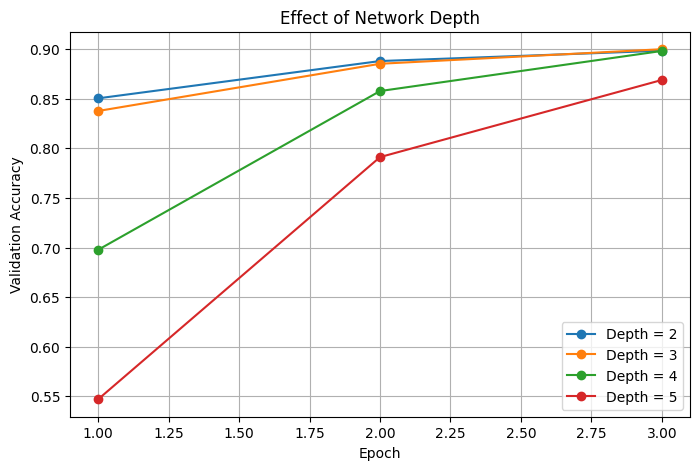

In [59]:
depth_configs = {
    2: [128, 64],
    3: [128, 64, 32],
    4: [128, 64, 32, 16],
    5: [128, 64, 32, 16, 8]
}

depth_results = {}

for depth, architecture in depth_configs.items():
    print(f"\nTraining with {depth} Hidden Layers: {architecture}")

    depth_results[depth] = train_model(
        learning_rate=0.01,
        batch_size=64,
        epochs=3,
        hidden_layers=architecture
    )

print("\nFinal Validation Accuracies:")

for depth in depth_configs:
    final_acc = depth_results[depth]["val_accuracies"][-1]
    print(f"Depth {depth}: {final_acc:.4f}")


plt.figure(figsize=(8, 5))

for depth in depth_configs:
    plt.plot(
        range(1, len(depth_results[depth]["val_accuracies"]) + 1),
        depth_results[depth]["val_accuracies"],
        marker="o",
        label=f"Depth = {depth}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Network Depth")
plt.legend()
plt.grid()
plt.show()


Training with Width = 64: [64, 64]
Epoch 1/3 | Train Loss: 1.1864 | Train Acc: 0.6997 | Val Loss: 0.6070 | Val Acc: 0.8455 | Time: 6.29s
Epoch 2/3 | Train Loss: 0.4829 | Train Acc: 0.8696 | Val Loss: 0.4254 | Val Acc: 0.8814 | Time: 6.94s
Epoch 3/3 | Train Loss: 0.3808 | Train Acc: 0.8906 | Val Loss: 0.3673 | Val Acc: 0.8968 | Time: 6.27s

Training with Width = 128: [128, 128]
Epoch 1/3 | Train Loss: 1.1919 | Train Acc: 0.6972 | Val Loss: 0.5784 | Val Acc: 0.8502 | Time: 6.97s
Epoch 2/3 | Train Loss: 0.4621 | Train Acc: 0.8774 | Val Loss: 0.4086 | Val Acc: 0.8900 | Time: 6.28s
Epoch 3/3 | Train Loss: 0.3651 | Train Acc: 0.8971 | Val Loss: 0.3543 | Val Acc: 0.9015 | Time: 6.95s

Training with Width = 256: [256, 256]
Epoch 1/3 | Train Loss: 1.1241 | Train Acc: 0.7386 | Val Loss: 0.5404 | Val Acc: 0.8618 | Time: 6.25s
Epoch 2/3 | Train Loss: 0.4350 | Train Acc: 0.8841 | Val Loss: 0.3888 | Val Acc: 0.8948 | Time: 6.95s
Epoch 3/3 | Train Loss: 0.3473 | Train Acc: 0.9015 | Val Loss: 0.3371 

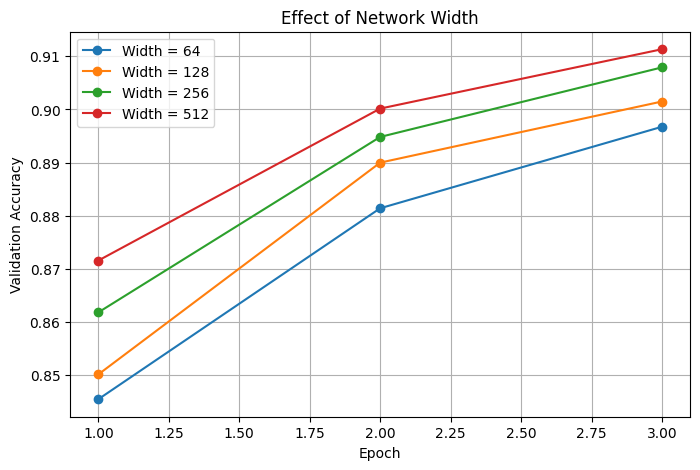

In [60]:
width_configs = {
    64: [64, 64],
    128: [128, 128],
    256: [256, 256],
    512: [512, 512]
}

width_results = {}

for width, architecture in width_configs.items():
    print(f"\nTraining with Width = {width}: {architecture}")

    width_results[width] = train_model(
        learning_rate=0.01,
        batch_size=64,
        epochs=3,
        hidden_layers=architecture
    )

print("\nFinal Validation Accuracies:")

for width in width_configs:
    final_acc = width_results[width]["val_accuracies"][-1]
    print(f"Width {width}: {final_acc:.4f}")

plt.figure(figsize=(8, 5))

for width in width_configs:
    plt.plot(
        range(1, len(width_results[width]["val_accuracies"]) + 1),
        width_results[width]["val_accuracies"],
        marker="o",
        label=f"Width = {width}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Network Width")
plt.legend()
plt.grid()
plt.show()

In [61]:
# ============================================================
# C1 - ARCHITECTURE COMPARISON TABLE
# Depth + Width + Accuracy
# ============================================================

architecture_comparison = []


# -------------------------
# Depth Results
# -------------------------

for depth, result in depth_results.items():

    architecture_comparison.append({

        "Experiment": "Depth",

        "Configuration":
            str(depth) + " Hidden Layers",

        "Depth":
            depth,

        "Width":
            "-",

        "Validation Accuracy":
            result["val_accuracies"][-1]
    })


# -------------------------
# Width Results
# -------------------------

for width, result in width_results.items():

    architecture_comparison.append({

        "Experiment": "Width",

        "Configuration":
            f"{width} Neurons",

        "Depth":
            "-",

        "Width":
            width,

        "Validation Accuracy":
            result["val_accuracies"][-1]
    })


architecture_comparison_df = pd.DataFrame(
    architecture_comparison
)


print(
    "\nArchitecture Comparison Table:\n"
)

display(
    architecture_comparison_df.round(4)
)


Architecture Comparison Table:



,Experiment,Configuration,Depth,Width,Validation Accuracy
0,Depth,2 Hidden Layers,2,-,0.8984
1,Depth,3 Hidden Layers,3,-,0.8999
2,Depth,4 Hidden Layers,4,-,0.8982
3,Depth,5 Hidden Layers,5,-,0.8689
4,Width,64 Neurons,-,64,0.8968
5,Width,128 Neurons,-,128,0.9015
6,Width,256 Neurons,-,256,0.9079
7,Width,512 Neurons,-,512,0.9113


In [62]:
# ============================================================
# C1 - DEPTH x WIDTH INTERACTION
# ============================================================

depth_width_results = {}

depth_values = [2, 3, 4, 5]

width_values = [64, 128, 256, 512]


for depth in depth_values:

    for width in width_values:

        architecture = [
            width
        ] * depth

        print(
            "\n" + "=" * 60
        )

        print(
            f"Testing Depth = {depth}, "
            f"Width = {width}"
        )

        print(
            "Architecture:",
            architecture
        )

        result = train_model(

            learning_rate=best_lr,

            batch_size=best_bs,

            epochs=3,

            hidden_layers=architecture
        )

        depth_width_results[
            (depth, width)
        ] = result


print(
    "\nDepth x Width experiments completed."
)


Testing Depth = 2, Width = 64
Architecture: [64, 64]
Epoch 1/3 | Train Loss: 0.3161 | Train Acc: 0.9041 | Val Loss: 0.2020 | Val Acc: 0.9361 | Time: 10.70s
Epoch 2/3 | Train Loss: 0.1409 | Train Acc: 0.9576 | Val Loss: 0.1545 | Val Acc: 0.9531 | Time: 10.01s
Epoch 3/3 | Train Loss: 0.1024 | Train Acc: 0.9674 | Val Loss: 0.1239 | Val Acc: 0.9611 | Time: 10.42s

Testing Depth = 2, Width = 128
Architecture: [128, 128]
Epoch 1/3 | Train Loss: 0.2866 | Train Acc: 0.9119 | Val Loss: 0.1752 | Val Acc: 0.9496 | Time: 10.61s
Epoch 2/3 | Train Loss: 0.1237 | Train Acc: 0.9619 | Val Loss: 0.1468 | Val Acc: 0.9533 | Time: 10.56s
Epoch 3/3 | Train Loss: 0.0854 | Train Acc: 0.9735 | Val Loss: 0.1241 | Val Acc: 0.9626 | Time: 10.49s

Testing Depth = 2, Width = 256
Architecture: [256, 256]
Epoch 1/3 | Train Loss: 0.2749 | Train Acc: 0.9162 | Val Loss: 0.1573 | Val Acc: 0.9503 | Time: 10.78s
Epoch 2/3 | Train Loss: 0.1131 | Train Acc: 0.9648 | Val Loss: 0.1184 | Val Acc: 0.9641 | Time: 10.44s
Epoch 3/

In [63]:
# ============================================================
# C1 - DEPTH x WIDTH RESULTS TABLE
# ============================================================

depth_width_table = []

for (
    depth,
    width
), result in depth_width_results.items():

    final_val_accuracy = (
        result["val_accuracies"][-1]
    )

    total_time = (
        result["total_training_time"]
    )


    depth_width_table.append({

        "Depth":
            depth,

        "Width":
            width,

        "Architecture":
            str([width] * depth),

        "Final Val Accuracy":
            final_val_accuracy,

        "Training Time (s)":
            total_time
    })


depth_width_df = pd.DataFrame(
    depth_width_table
)


depth_width_df = (
    depth_width_df
    .sort_values(
        "Final Val Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nDepth x Width Interaction Results:\n"
)

display(
    depth_width_df.round(4)
)


Depth x Width Interaction Results:



,Depth,Width,Architecture,Final Val Accuracy,Training Time (s)
0,2,512,"[512, 512]",0.9722,31.9262
1,3,256,"[256, 256, 256]",0.9722,33.7301
2,5,512,"[512, 512, 512, 512, 512]",0.9686,38.6412
3,2,256,"[256, 256]",0.9678,31.6157
4,3,128,"[128, 128, 128]",0.9674,33.0223
5,4,128,"[128, 128, 128, 128]",0.9668,34.8578
6,4,512,"[512, 512, 512, 512]",0.9664,35.5728
7,5,256,"[256, 256, 256, 256, 256]",0.9664,38.0733
8,4,256,"[256, 256, 256, 256]",0.9658,35.5782
9,3,512,"[512, 512, 512]",0.9648,33.7794


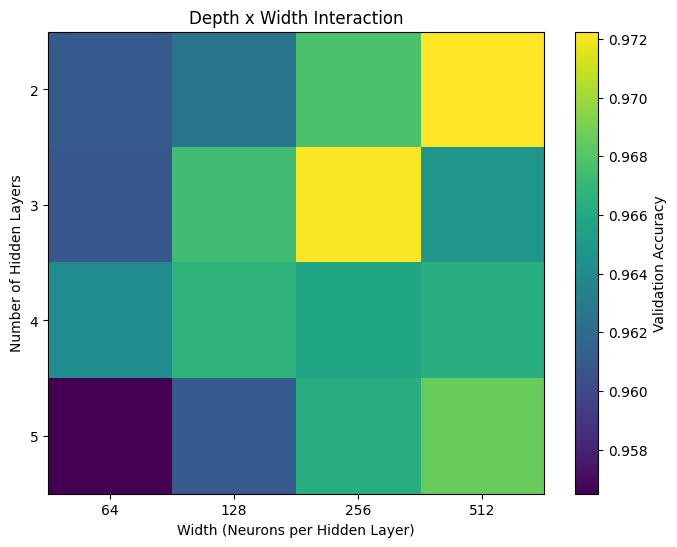

In [64]:
# ============================================================
# C1 - DEPTH x WIDTH HEATMAP
# ============================================================

interaction_matrix = (
    depth_width_df
    .pivot(
        index="Depth",
        columns="Width",
        values="Final Val Accuracy"
    )
)


plt.figure(figsize=(8, 6))

plt.imshow(
    interaction_matrix.values,
    aspect="auto"
)

plt.xticks(
    range(len(width_values)),
    width_values
)

plt.yticks(
    range(len(depth_values)),
    depth_values
)

plt.xlabel(
    "Width (Neurons per Hidden Layer)"
)

plt.ylabel(
    "Number of Hidden Layers"
)

plt.title(
    "Depth x Width Interaction"
)

plt.colorbar(
    label="Validation Accuracy"
)

plt.show()

In [65]:
# ============================================================
# C1 - BEST CONFIGURATION
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "BEST HYPERPARAMETERS"
)

print(
    "=" * 70
)


# -------------------------
# Best Learning Rate
# -------------------------

best_lr = max(

    results,

    key=lambda lr:
        results[lr]
        ["val_accuracies"][-1]
)


print(
    "Best Learning Rate:",
    best_lr
)


# -------------------------
# Best Batch Size
# -------------------------

best_bs = max(

    batch_results,

    key=lambda bs:
        batch_results[bs]
        ["val_accuracies"][-1]
)


print(
    "Best Batch Size:",
    best_bs
)


# -------------------------
# Best Depth x Width
# -------------------------

best_architecture_row = (
    depth_width_df
    .iloc[0]
)


best_depth = int(
    best_architecture_row[
        "Depth"
    ]
)

best_width = int(
    best_architecture_row[
        "Width"
    ]
)

best_architecture = [
    best_width
] * best_depth


best_architecture_accuracy = (
    best_architecture_row[
        "Final Val Accuracy"
    ]
)


print(
    "Best Depth:",
    best_depth
)

print(
    "Best Width:",
    best_width
)

print(
    "Best Architecture:",
    best_architecture
)

print(
    "Best Architecture Validation Accuracy:",
    f"{best_architecture_accuracy:.4f}"
)


BEST HYPERPARAMETERS
Best Learning Rate: 0.1
Best Batch Size: 16
Best Depth: 2
Best Width: 512
Best Architecture: [512, 512]
Best Architecture Validation Accuracy: 0.9722


In [66]:
# ============================================================
# C1 - FINAL MODEL USING BEST CONFIGURATION
# ============================================================

final_hidden_layers = best_architecture


print(
    "Final Architecture:",
    final_hidden_layers
)

print(
    "Final Learning Rate:",
    best_lr
)

print(
    "Final Batch Size:",
    best_bs
)


final_results = train_model(

    learning_rate=best_lr,

    batch_size=best_bs,

    epochs=3,

    hidden_layers=final_hidden_layers
)


print(
    "\nFinal Model Training Completed!"
)


test_loader = DataLoader(

    test_dataset,

    batch_size=best_bs,

    shuffle=False
)


print(
    "Test DataLoader is ready!"
)

Final Architecture: [512, 512]
Final Learning Rate: 0.1
Final Batch Size: 16
Epoch 1/3 | Train Loss: 0.2595 | Train Acc: 0.9215 | Val Loss: 0.1414 | Val Acc: 0.9568 | Time: 10.36s
Epoch 2/3 | Train Loss: 0.1044 | Train Acc: 0.9676 | Val Loss: 0.1006 | Val Acc: 0.9697 | Time: 10.02s
Epoch 3/3 | Train Loss: 0.0658 | Train Acc: 0.9792 | Val Loss: 0.0896 | Val Acc: 0.9732 | Time: 10.49s

Final Model Training Completed!
Test DataLoader is ready!


In [67]:
def evaluate_model(model, test_loader):

    model.eval()

    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    return accuracy, all_labels, all_predictions



In [68]:
 test_accuracy, test_labels, test_predictions = evaluate_model(
    final_results["model"],
    test_loader
)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9710


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(test_labels, test_predictions)

precision = precision_score(
    test_labels,
    test_predictions,
    average="weighted"
)

recall = recall_score(
    test_labels,
    test_predictions,
    average="weighted"
)

f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


Accuracy : 0.9710
Precision: 0.9712
Recall   : 0.9710
F1 Score : 0.9710


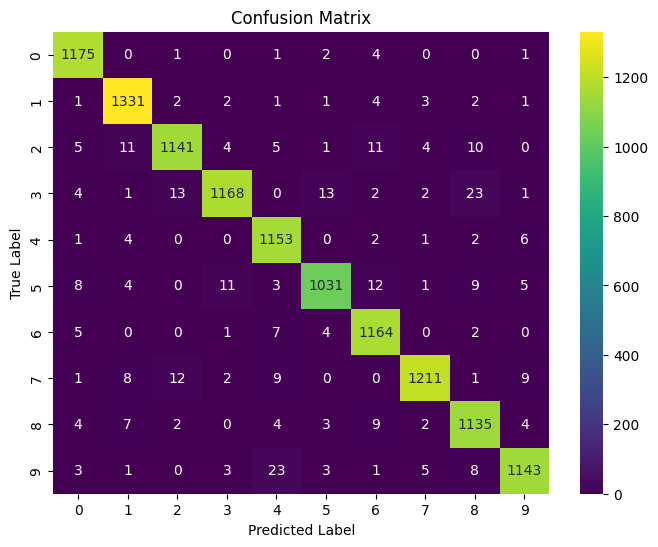

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Total Misclassified Examples: 348


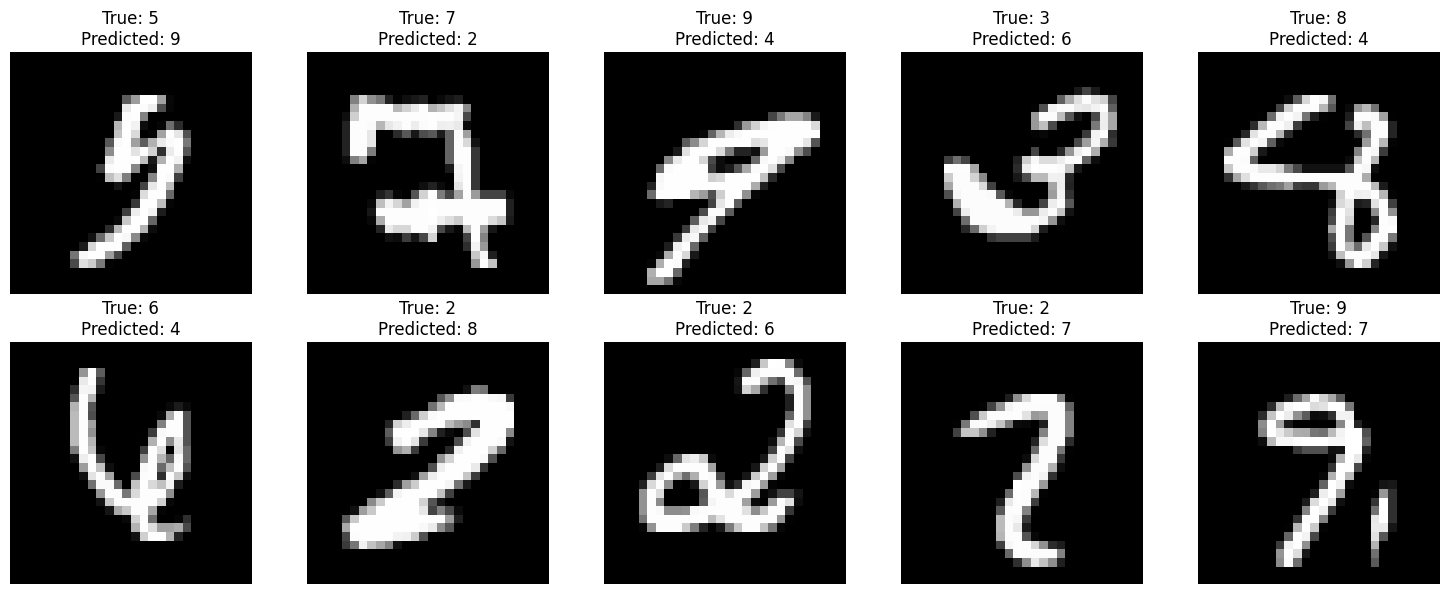

In [71]:
# ============================================================
# C1 - MISCLASSIFIED EXAMPLES
# ============================================================

import matplotlib.pyplot as plt

# Find wrong predictions
misclassified_indices = []

for i in range(len(test_labels)):
    if test_labels[i] != test_predictions[i]:
        misclassified_indices.append(i)

print("Total Misclassified Examples:", len(misclassified_indices))


# Show some misclassified images
num_examples = 10

plt.figure(figsize=(15, 6))

for i in range(num_examples):

    idx = misclassified_indices[i]

    image, true_label = test_dataset[idx]

    predicted_label = test_predictions[idx]

    plt.subplot(2, 5, i + 1)

    plt.imshow(image.squeeze(), cmap="gray")

    plt.title(
        f"True: {true_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# C2 - FINAL PERFORMANCE SUMMARY
# ============================================================
import pandas as pd

final_summary = pd.DataFrame({
    "Model": [
        "Binary Logistic Regression",
        "Softmax Regression",
        "Best Neural Network"
    ],

    "Classification": [
        "Binary (0 vs 1)",
        "Multiclass (10 classes)",
        "Multiclass (10 classes)"
    ],

    "Test Accuracy": [
        f"{test_acc.item() * 100:.2f}%",
        f"{test_acc_scratch.item() * 100:.2f}%",
        f"{test_accuracy * 100:.2f}%"
    ],

    "Model Type": [
        "Linear",
        "Linear",
        "Nonlinear"
    ],

    "Optimization": [
        "Gradient Descent",
        "Gradient Descent",
        "Mini-batch SGD"
    ]
})

final_summary

,Model,Classification,Test Accuracy,Model Type,Optimization
0,Binary Logistic Regression,Binary (0 vs 1),87.59%,Linear,Gradient Descent
1,Softmax Regression,Multiclass (10 classes),87.54%,Linear,Gradient Descent
2,Best Neural Network,Multiclass (10 classes),97.10%,Nonlinear,Mini-batch SGD


In [73]:
# ============================================================
# PART D1 - BASIC CNN
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader


# ------------------------------------------------------------
# 1. DataLoaders
# ------------------------------------------------------------

cnn_train_loader = DataLoader(
    train_dataset,
    batch_size=best_bs,
    shuffle=True
)

cnn_val_loader = DataLoader(
    val_dataset,
    batch_size=best_bs,
    shuffle=False
)


# ------------------------------------------------------------
# 2. CNN Architecture
# ------------------------------------------------------------

class SimpleCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # 1 -> 32 feature maps
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # 32 -> 64 feature maps
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 128),

            nn.ReLU(),

            nn.Linear(128, 10)
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# ------------------------------------------------------------
# 3. Create Model
# ------------------------------------------------------------

cnn_model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.SGD(
    cnn_model.parameters(),
    lr=best_lr
)


# ------------------------------------------------------------
# 4. Training
# ------------------------------------------------------------

cnn_epochs = 3

cnn_train_acc = []
cnn_val_acc = []

print("CNN Training Started...\n")


for epoch in range(cnn_epochs):

    # -------------------------
    # Training
    # -------------------------

    cnn_model.train()

    correct = 0
    total = 0

    for images, labels in cnn_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        cnn_optimizer.zero_grad()

        outputs = cnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        cnn_optimizer.step()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------

    cnn_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in cnn_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model(images)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total


    cnn_train_acc.append(train_accuracy)
    cnn_val_acc.append(val_accuracy)


    print(
        f"Epoch {epoch + 1}/{cnn_epochs} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Validation Accuracy: {val_accuracy:.4f}"
    )


print("\nCNN Training Completed!")
print(f"Final Validation Accuracy: {cnn_val_acc[-1]:.4f}")

CNN Training Started...

Epoch 1/3 | Train Accuracy: 0.9329 | Validation Accuracy: 0.9768
Epoch 2/3 | Train Accuracy: 0.9820 | Validation Accuracy: 0.9782
Epoch 3/3 | Train Accuracy: 0.9887 | Validation Accuracy: 0.9807

CNN Training Completed!
Final Validation Accuracy: 0.9807


In [74]:
# ============================================================
# CNN - TEST SET EVALUATION
# ============================================================

cnn_model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cnn_test_accuracy = correct / total

print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")

CNN Test Accuracy: 0.9812


In [75]:
# ============================================================
# CNN vs Fully Connected NN
# ============================================================

fc_test_accuracy = test_accuracy
cnn_accuracy = cnn_test_accuracy

print("======================================")
print("FC NN vs CNN Comparison")
print("======================================")

print(f"Fully Connected NN Accuracy: {fc_test_accuracy:.4f}")
print(f"CNN Accuracy:                {cnn_accuracy:.4f}")

improvement = (cnn_accuracy - fc_test_accuracy) * 100

# ============================================================
# CNN vs Fully Connected NN - Final Comparison
# ============================================================

fc_params = sum(
    p.numel()
    for p in final_results["model"].parameters()
)

cnn_params = sum(
    p.numel()
    for p in cnn_model.parameters()
)

print("==========================================")
print("FINAL MODEL COMPARISON")
print("==========================================")

print(f"Fully Connected NN:")
print(f"Accuracy: {fc_test_accuracy * 100:.2f}%")
print(f"Parameters: {fc_params:,}")

print("\nCNN:")
print(f"Accuracy: {cnn_accuracy * 100:.2f}%")
print(f"Parameters: {cnn_params:,}")

print("\n==========================================")
print(f"CNN Accuracy Improvement: {improvement:.2f} percentage points")
print("==========================================")

print(f"\nCNN Improvement: {improvement:.2f} percentage points")

FC NN vs CNN Comparison
Fully Connected NN Accuracy: 0.9710
CNN Accuracy:                0.9812
FINAL MODEL COMPARISON
Fully Connected NN:
Accuracy: 97.10%
Parameters: 669,706

CNN:
Accuracy: 98.12%
Parameters: 421,642

CNN Accuracy Improvement: 1.02 percentage points

CNN Improvement: 1.02 percentage points


In [76]:
# ============================================================
# D2.1 - DROPOUT ANALYSIS
# ============================================================

class DropoutNN(nn.Module):

    def __init__(self, dropout_rate, hidden_layers=[256, 256]):

        super().__init__()

        layers = []

        input_size = 28 * 28

        for hidden_size in hidden_layers:

            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))

            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))

        self.network = nn.Sequential(*layers)

        # Xavier Initialization
        for layer in self.network:

            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.network(x)

In [77]:
# ============================================================
# Train Dropout Models
# ============================================================

def train_dropout_model(dropout_rate, epochs=3):

    train_loader = DataLoader(
        train_dataset,
        batch_size=best_bs,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=best_bs,
        shuffle=False
    )

    model = DropoutNN(
        dropout_rate=dropout_rate,
        hidden_layers=[256, 256]
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=best_lr
    )

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_accuracy = correct / total

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                predictions = outputs.argmax(dim=1)

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_accuracy = val_correct / val_total

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(
            f"Dropout {dropout_rate} | "
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    return {
        "model": model,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }

In [78]:
# ============================================================
# Test Different Dropout Rates
# ============================================================

dropout_rates = [0.1, 0.3, 0.5, 0.7]

dropout_results = {}

for rate in dropout_rates:

    print("\n==============================")
    print(f"Testing Dropout = {rate}")
    print("==============================")

    dropout_results[rate] = train_dropout_model(
        dropout_rate=rate,
        epochs=3
    )


Testing Dropout = 0.1
Dropout 0.1 | Epoch 1/3 | Train Acc: 0.9090 | Val Acc: 0.9558
Dropout 0.1 | Epoch 2/3 | Train Acc: 0.9595 | Val Acc: 0.9672
Dropout 0.1 | Epoch 3/3 | Train Acc: 0.9716 | Val Acc: 0.9708

Testing Dropout = 0.3
Dropout 0.3 | Epoch 1/3 | Train Acc: 0.8866 | Val Acc: 0.9511
Dropout 0.3 | Epoch 2/3 | Train Acc: 0.9437 | Val Acc: 0.9593
Dropout 0.3 | Epoch 3/3 | Train Acc: 0.9571 | Val Acc: 0.9643

Testing Dropout = 0.5
Dropout 0.5 | Epoch 1/3 | Train Acc: 0.8473 | Val Acc: 0.9365
Dropout 0.5 | Epoch 2/3 | Train Acc: 0.9149 | Val Acc: 0.9550
Dropout 0.5 | Epoch 3/3 | Train Acc: 0.9285 | Val Acc: 0.9497

Testing Dropout = 0.7
Dropout 0.7 | Epoch 1/3 | Train Acc: 0.7341 | Val Acc: 0.9164
Dropout 0.7 | Epoch 2/3 | Train Acc: 0.8389 | Val Acc: 0.9243
Dropout 0.7 | Epoch 3/3 | Train Acc: 0.8597 | Val Acc: 0.9344


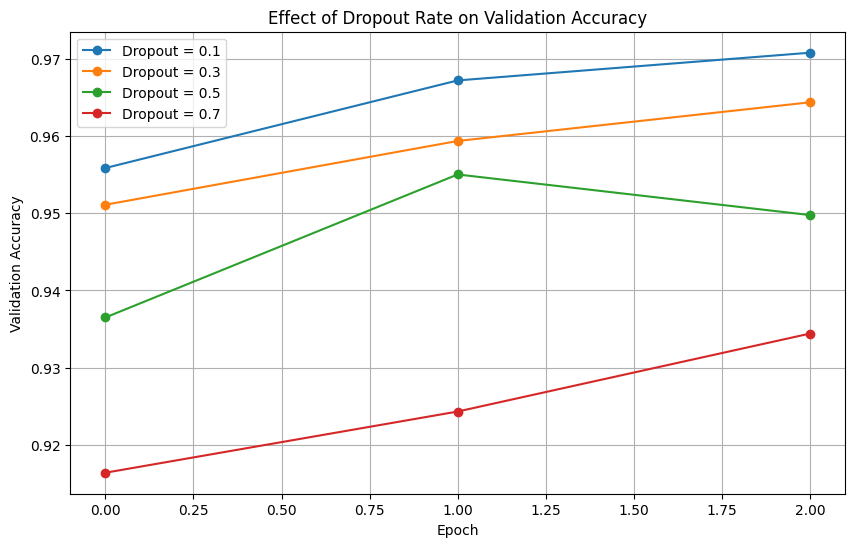

In [79]:
# ============================================================
# Dropout Analysis Plot
# ============================================================


plt.figure(figsize=(10, 6))

for rate in dropout_rates:

    plt.plot(
        dropout_results[rate]["val_accuracies"],
        marker="o",
        label=f"Dropout = {rate}"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Dropout Rate on Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

In [80]:
# ============================================================
# D2.2 - BATCH NORMALIZATION
# ============================================================

class BatchNormNN(nn.Module):

    def __init__(self, hidden_layers=[256, 256]):

        super().__init__()

        layers = []

        input_size = 28 * 28

        for hidden_size in hidden_layers:

            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())

            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))

        self.network = nn.Sequential(*layers)

        # Xavier Initialization
        for layer in self.network:

            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.network(x)

In [81]:
# ============================================================
# Train Batch Normalization Model
# ============================================================

def train_batchnorm_model(epochs=3):

    train_loader = DataLoader(
        train_dataset,
        batch_size=best_bs,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=best_bs,
        shuffle=False
    )

    model = BatchNormNN(
        hidden_layers=[256, 256]
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=best_lr
    )

    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_accuracy = correct / total

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                predictions = outputs.argmax(dim=1)

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_accuracy = val_correct / val_total

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        print(
            f"BatchNorm | "
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

    return {
        "model": model,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies
    }

In [82]:
# ============================================================
# Run Batch Normalization Experiment
# ============================================================

print("==============================")
print("Batch Normalization Experiment")
print("==============================")

batchnorm_results = train_batchnorm_model(
    epochs=3
)

print("\nBatch Normalization Training Completed!")

Batch Normalization Experiment
BatchNorm | Epoch 1/3 | Train Acc: 0.9118 | Val Acc: 0.9657
BatchNorm | Epoch 2/3 | Train Acc: 0.9554 | Val Acc: 0.9708
BatchNorm | Epoch 3/3 | Train Acc: 0.9648 | Val Acc: 0.9748

Batch Normalization Training Completed!


In [83]:
# ============================================================
# D2.3 - BATCH NORMALIZATION + DROPOUT
# ============================================================

class BatchNormDropoutNN(nn.Module):

    def __init__(self, dropout_rate=0.3, hidden_layers=[256, 256]):

        super().__init__()

        layers = []

        input_size = 28 * 28

        for hidden_size in hidden_layers:

            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))

            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))

        self.network = nn.Sequential(*layers)

        for layer in self.network:

            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):

        x = x.view(x.size(0), -1)

        return self.network(x)

In [84]:
# ============================================================
# Train BatchNorm + Dropout Model
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=best_bs,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=best_bs,
    shuffle=False
)

bn_dropout_model = BatchNormDropoutNN(
    dropout_rate=0.3,
    hidden_layers=[256, 256]
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    bn_dropout_model.parameters(),
    lr=best_lr
)

bn_dropout_train_acc = []
bn_dropout_val_acc = []

print("====================================")
print("BatchNorm + Dropout Experiment")
print("====================================")

for epoch in range(3):

    bn_dropout_model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = bn_dropout_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total


    bn_dropout_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = bn_dropout_model(images)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total

    bn_dropout_train_acc.append(train_accuracy)
    bn_dropout_val_acc.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/3 | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

print("\nBatchNorm + Dropout Training Completed!")
print(
    f"Final Validation Accuracy: "
    f"{bn_dropout_val_acc[-1]:.4f}"
)

BatchNorm + Dropout Experiment
Epoch 1/3 | Train Acc: 0.8690 | Val Acc: 0.9537
Epoch 2/3 | Train Acc: 0.9197 | Val Acc: 0.9647
Epoch 3/3 | Train Acc: 0.9322 | Val Acc: 0.9666

BatchNorm + Dropout Training Completed!
Final Validation Accuracy: 0.9666


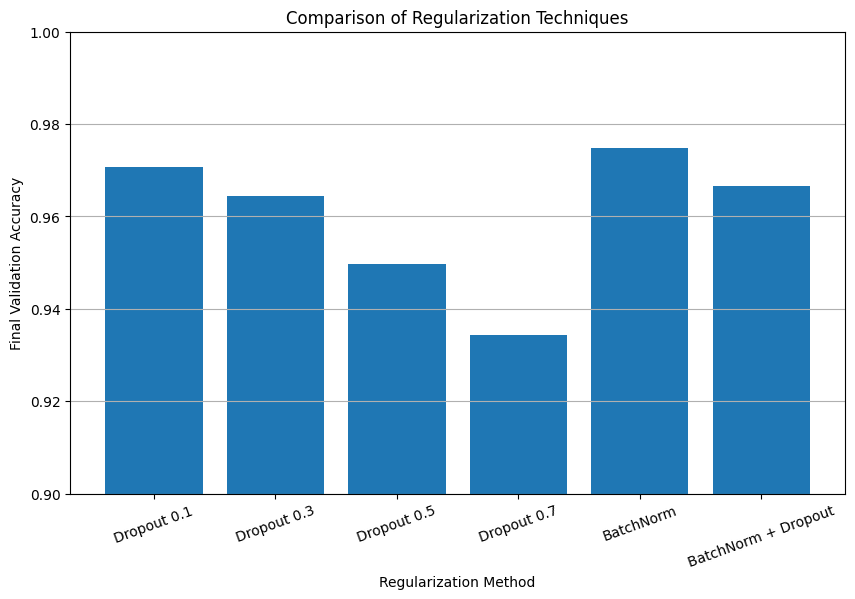

In [85]:
# ============================================================
# D2 - FINAL REGULARIZATION COMPARISON
# ============================================================

regularization_methods = [
    "Dropout 0.1",
    "Dropout 0.3",
    "Dropout 0.5",
    "Dropout 0.7",
    "BatchNorm",
    "BatchNorm + Dropout"
]

regularization_accuracies = [
    dropout_results[0.1]["val_accuracies"][-1],
    dropout_results[0.3]["val_accuracies"][-1],
    dropout_results[0.5]["val_accuracies"][-1],
    dropout_results[0.7]["val_accuracies"][-1],
    batchnorm_results["val_accuracies"][-1],
    bn_dropout_val_acc[-1]
]

plt.figure(figsize=(10, 6))

plt.bar(
    regularization_methods,
    regularization_accuracies
)

plt.xlabel("Regularization Method")
plt.ylabel("Final Validation Accuracy")
plt.title("Comparison of Regularization Techniques")

plt.ylim(0.90, 1.00)
plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

In [86]:
# ============================================================
# D2 - FINAL RESULTS
# ============================================================

print("==========================================")
print("D2 - FINAL REGULARIZATION RESULTS")
print("==========================================")

for method, accuracy in zip(
    regularization_methods,
    regularization_accuracies
):
    print(f"{method}: {accuracy:.4f}")

best_method = regularization_methods[
    np.argmax(regularization_accuracies)
]

best_accuracy = max(regularization_accuracies)

print("\n------------------------------------------")
print(f"Best Method: {best_method}")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")
print("------------------------------------------")

D2 - FINAL REGULARIZATION RESULTS
Dropout 0.1: 0.9708
Dropout 0.3: 0.9643
Dropout 0.5: 0.9497
Dropout 0.7: 0.9344
BatchNorm: 0.9748
BatchNorm + Dropout: 0.9666

------------------------------------------
Best Method: BatchNorm
Best Validation Accuracy: 0.9748
------------------------------------------
